#Analyse Exploratoire des Données (EDA) - Mental Health Dataset

---
- **Analyse exploratoire des données (EDA)** : Il s'agit de la première étape essentielle de tout projet de science des données. Elle permet de **comprendre la structure du jeu de données**, d’**identifier les anomalies**, de **nettoyer les données**, et de **résumer les principales tendances** avant d’appliquer des modèles statistiques ou de machine learning.

- **Jeu de données utilisé** : Ce jeu de données est **une simulation synthétique** représentant les résultats d'une enquête mondiale sur la santé mentale, avec **10 000 répondants**. Il simule une diversité de profils démographiques, de modes de vie et de variables liées à la santé mentale. L’objectif est de **reproduire la richesse des enquêtes réelles tout en respectant la confidentialité et l’éthique**.

- **Variables incluses (14 colonnes)** :  
  - Démographiques et professionnelles : `age`, `gender`, `employment_status`, `work_environment`  
  - Antécédents et comportements : `mental_health_history`, `seeks_treatment`, `stress_level`, `sleep_hours`, `physical_activity_days`  
  - Scores psychologiques : `depression_score`, `anxiety_score`, `social_support_score`, `productivity_score`  
  - Indicateur global : `mental_health_risk`
'


#**Partie de Hadil Barzani**

## 1. Chargement et aperçu initial des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import missingno as msno
from sklearn.preprocessing import StandardScaler

DATASET: https://www.kaggle.com/datasets/mahdimashayekhi/mental-health/data?select=mental_health_dataset.csv

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mental_health_dataset.csv to mental_health_dataset (2).csv


In [ ]:
import pandas as pd
df_Original= pd.read_csv('mental_health_dataset.csv')
df=df_Original.copy()

df.head(30)

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High
5,38,Female,Unemployed,On-site,Yes,Yes,3,9.9,3,17,9,63,69.3,Medium
6,56,Non-binary,Employed,Remote,No,Yes,2,5.5,1,25,3,87,63.1,Medium
7,36,Male,Student,Remote,No,No,8,7.1,5,25,8,72,58.4,Medium
8,40,Male,Employed,Hybrid,No,No,7,6.5,6,28,6,46,60.4,Medium
9,28,Female,Employed,Remote,No,No,8,3.1,0,7,18,88,93.2,Medium


In [ ]:
#Column names
df.columns

Index(['age', 'gender', 'employment_status', 'work_environment',
       'mental_health_history', 'seeks_treatment', 'stress_level',
       'sleep_hours', 'physical_activity_days', 'depression_score',
       'anxiety_score', 'social_support_score', 'productivity_score',
       'mental_health_risk'],
      dtype='object')

In [ ]:
#shape of data
print(f"\n Shape of dataset: {df.shape[0]} rows × {df.shape[1]} columns")


 Shape of dataset: 10000 rows × 14 columns


In [ ]:
print("\n Dataset info:")
df.info()


 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   employment_status       10000 non-null  object 
 3   work_environment        10000 non-null  object 
 4   mental_health_history   10000 non-null  object 
 5   seeks_treatment         10000 non-null  object 
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  object 
dtypes: float64(2), int64(6)

In [ ]:
#Unique values per column
print("\n Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


 Unique values per column:
age: 48 unique values
gender: 4 unique values
employment_status: 4 unique values
work_environment: 3 unique values
mental_health_history: 2 unique values
seeks_treatment: 2 unique values
stress_level: 10 unique values
sleep_hours: 71 unique values
physical_activity_days: 8 unique values
depression_score: 31 unique values
anxiety_score: 22 unique values
social_support_score: 101 unique values
productivity_score: 546 unique values
mental_health_risk: 3 unique values


In [ ]:
print("\n Descriptive stats (categorical):")
display(df.describe(include=object))


 Descriptive stats (categorical):


,gender,employment_status,work_environment,mental_health_history,seeks_treatment,mental_health_risk
count,10000,10000,10000,10000,10000,10000
unique,4,4,3,2,2,3
top,Male,Employed,On-site,No,No,Medium
freq,4557,5868,5044,6969,6012,5892


In [ ]:
#Sample value counts for key categorical features

categorical_cols = [
    'gender',
    'Gender_clean',
    'employment_status',
    'work_environment',
    'mental_health_history',
    'seeks_treatment',
    'mental_health_risk'
]

print("\n Sample distributions of categorical features:")
for col in categorical_cols:
    if col in df.columns:
        print(f"\n {col} value counts:")
        print(df[col].value_counts(dropna=False))


 Sample distributions of categorical features:

 gender value counts:
gender
Male                 4557
Female               4457
Non-binary            520
Prefer not to say     466
Name: count, dtype: int64

 employment_status value counts:
employment_status
Employed         5868
Student          2043
Self-employed    1045
Unemployed       1044
Name: count, dtype: int64

 work_environment value counts:
work_environment
On-site    5044
Remote     3009
Hybrid     1947
Name: count, dtype: int64

 mental_health_history value counts:
mental_health_history
No     6969
Yes    3031
Name: count, dtype: int64

 seeks_treatment value counts:
seeks_treatment
No     6012
Yes    3988
Name: count, dtype: int64

 mental_health_risk value counts:
mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\n Descriptive stats (numeric):")
display(df[numeric_cols].describe())


 Descriptive stats (numeric):


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


## 2. Nettoyage préliminaire et vérification des valeurs manquantes

In [ ]:
print("\n Missing values per column:")
print(df.isnull().sum())


 Missing values per column:
age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64


In [ ]:
df['Gender_clean'] = df['gender'].replace(
    to_replace=['Prefer not to say', 'prefer not to say', 'PREFER NOT TO SAY'],
    value=np.nan
)

In [ ]:
# Calculate missing values and percentage for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Créer un dataframe pour afficher les résultats
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing_values,
    'Pourcentage (%)': missing_percentage
})



In [ ]:
# Filtrer pour n'afficher que les colonnes avec des valeurs manquantes
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values(
    'Pourcentage (%)', ascending=False)

In [ ]:
print("Valeurs manquantes par colonne:")
display(missing_df)

Valeurs manquantes par colonne:


,Valeurs manquantes,Pourcentage (%)
Gender_clean,466,4.66


<ipython-input-87-d65834766f3d>:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

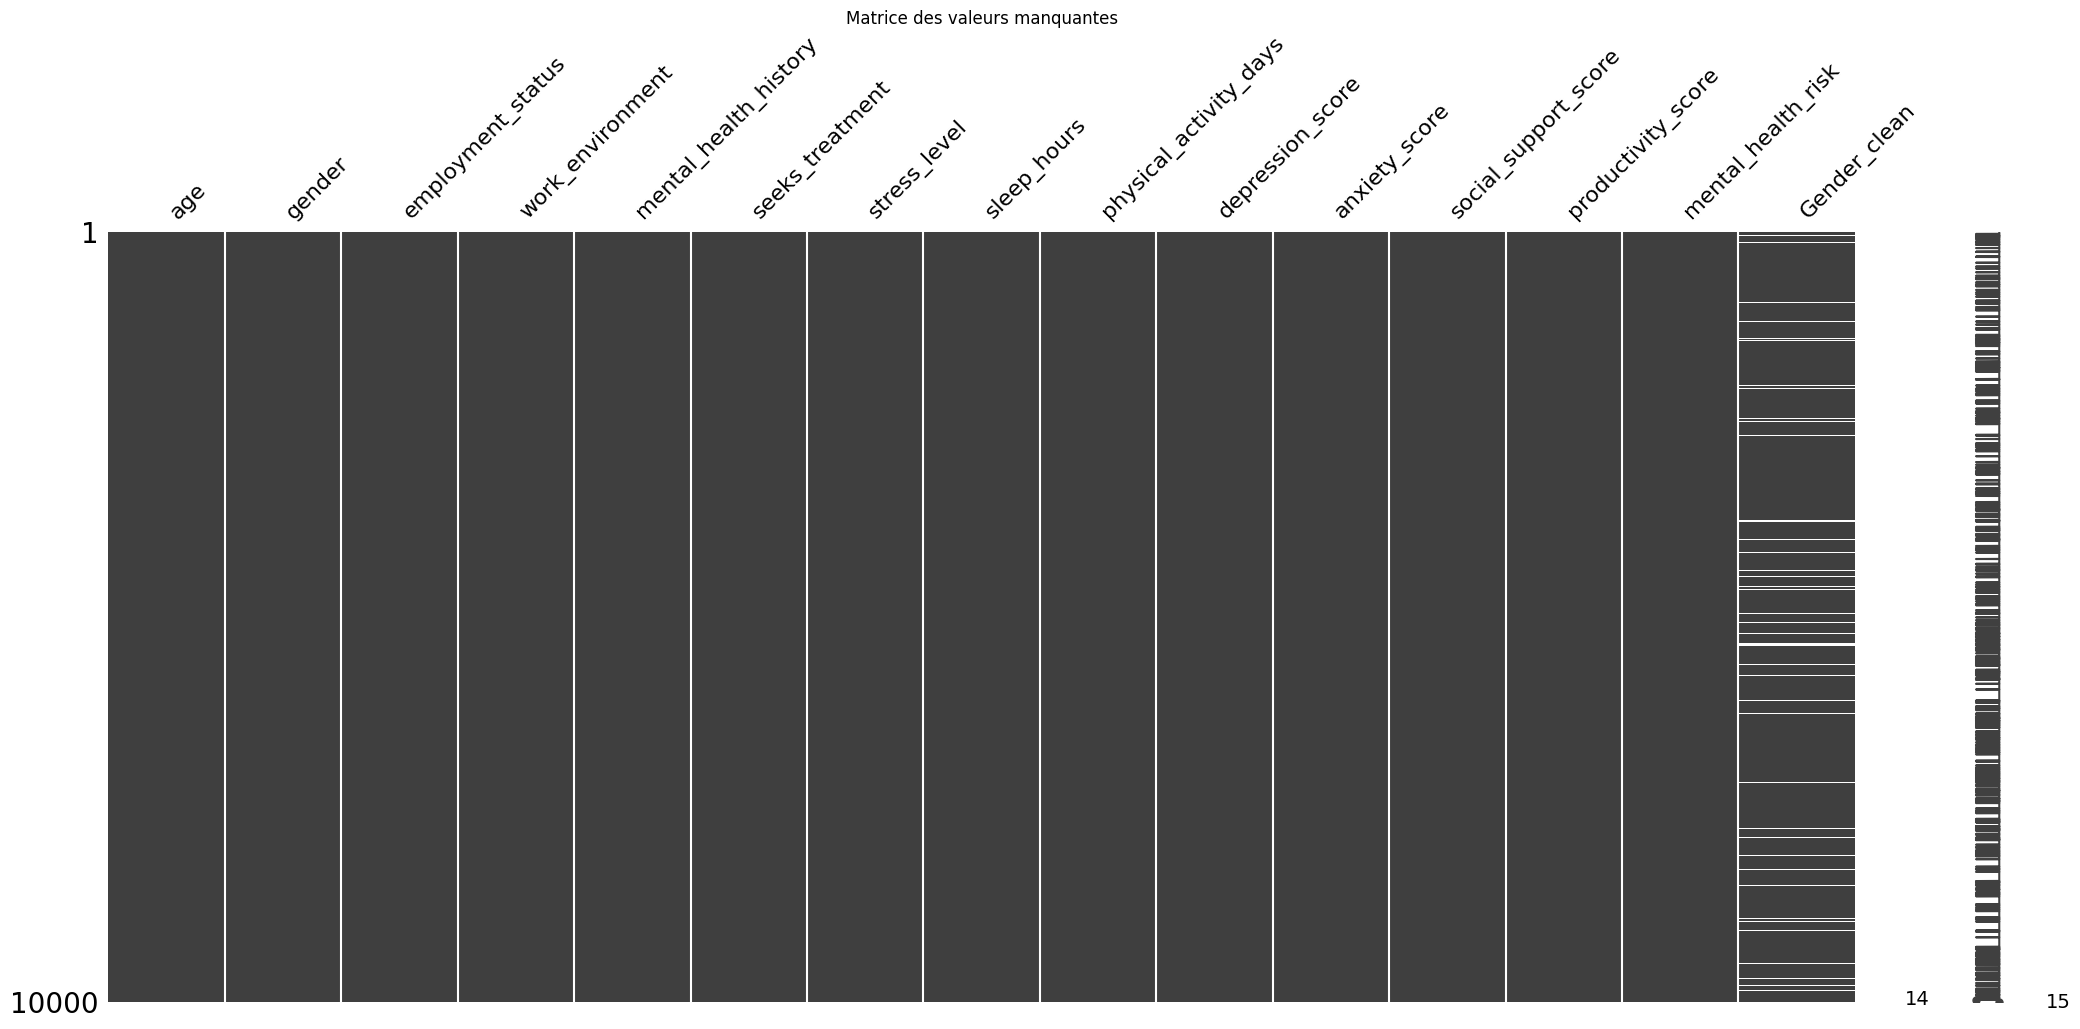

In [ ]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title('Matrice des valeurs manquantes')
plt.tight_layout()
plt.savefig('missing_values_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Analyse univariée

### 3.1 Variables numériques


Variable numérique: age

Descriptive Statistics:
count    10000.000000
mean        41.557600
std         13.749581
min         18.000000
25%         30.000000
50%         41.500000
75%         53.000000
max         65.000000
Name: age, dtype: float64

Skewness: -0.00

Interpretation of skewness: Approximately symmetric distribution.


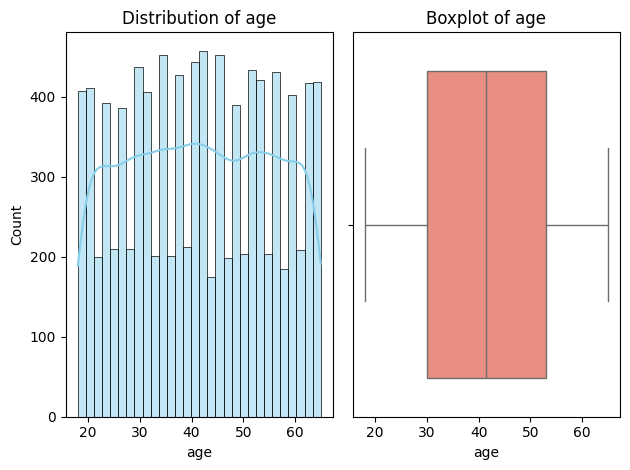


Variable numérique: sleep_hours

Descriptive Statistics:
count    10000.000000
mean         6.473000
std          1.473944
min          3.000000
25%          5.500000
50%          6.500000
75%          7.500000
max         10.000000
Name: sleep_hours, dtype: float64

Skewness: -0.00

Interpretation of skewness: Approximately symmetric distribution.


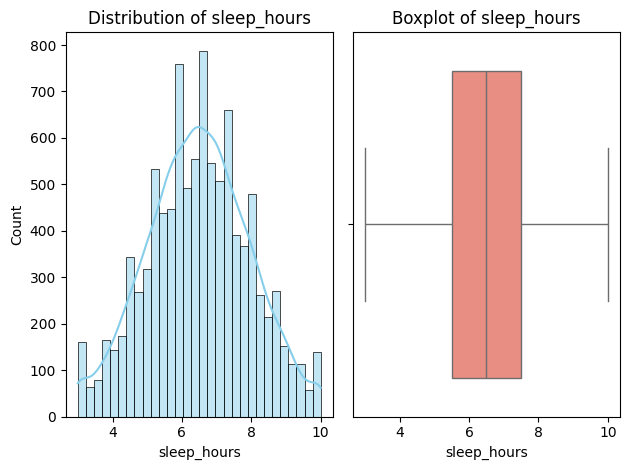


Variable numérique: physical_activity_days

Descriptive Statistics:
count    10000.000000
mean         3.505700
std          2.282737
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: physical_activity_days, dtype: float64

Skewness: -0.00

Interpretation of skewness: Approximately symmetric distribution.


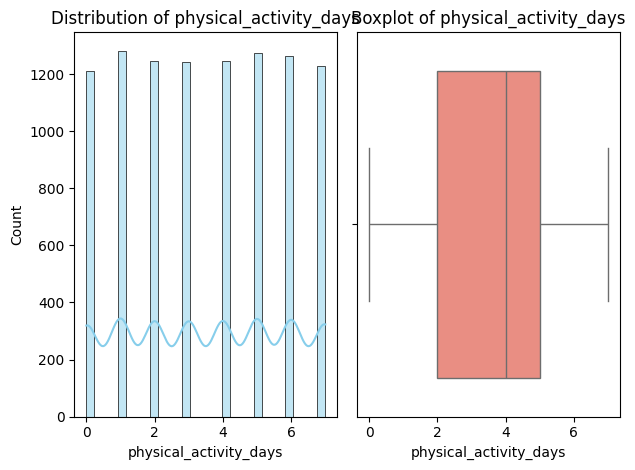


Variable numérique: depression_score

Descriptive Statistics:
count    10000.000000
mean        15.039900
std          8.990839
min          0.000000
25%          7.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: depression_score, dtype: float64

Skewness: 0.00

Interpretation of skewness: Approximately symmetric distribution.


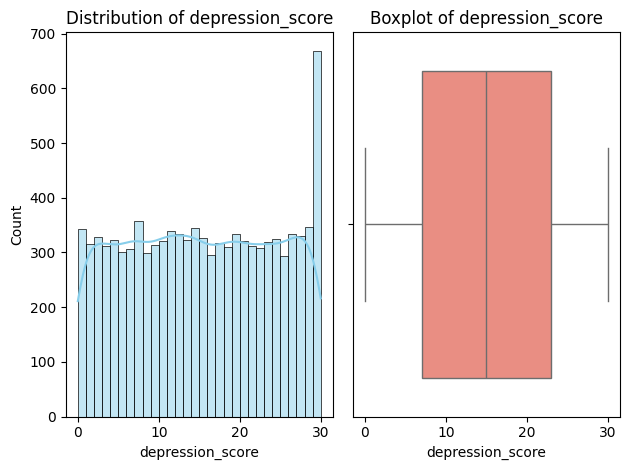


Variable numérique: anxiety_score

Descriptive Statistics:
count    10000.00000
mean        10.56180
std          6.32264
min          0.00000
25%          5.00000
50%         11.00000
75%         16.00000
max         21.00000
Name: anxiety_score, dtype: float64

Skewness: -0.02

Interpretation of skewness: Approximately symmetric distribution.


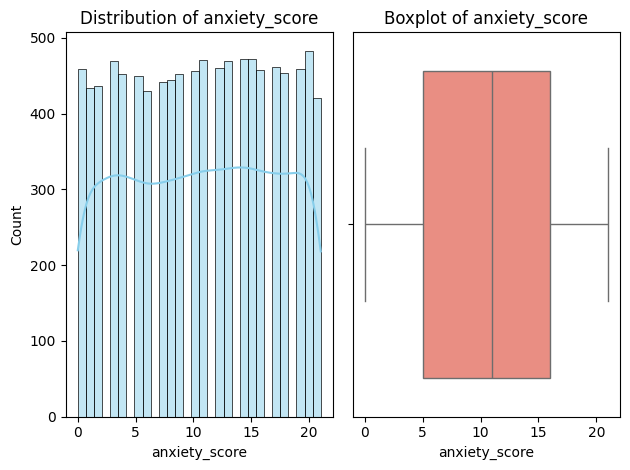


Variable numérique: social_support_score

Descriptive Statistics:
count    10000.000000
mean        50.117700
std         29.229278
min          0.000000
25%         25.000000
50%         50.000000
75%         76.000000
max        100.000000
Name: social_support_score, dtype: float64

Skewness: -0.00

Interpretation of skewness: Approximately symmetric distribution.


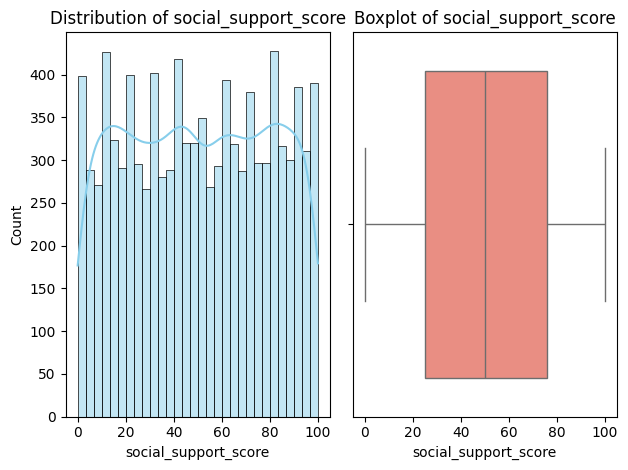


Variable numérique: stress_level

Descriptive Statistics:
count    10000.000000
mean         5.572000
std          2.887741
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: stress_level, dtype: float64

Skewness: -0.02

Interpretation of skewness: Approximately symmetric distribution.


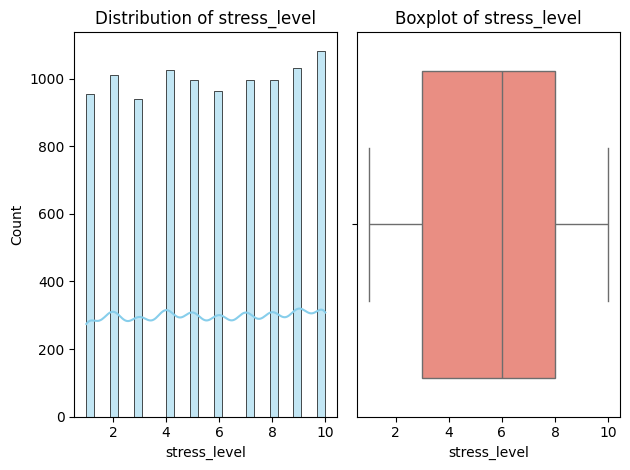


Variable numérique: productivity_score

Descriptive Statistics:
count    10000.000000
mean        77.312210
std         14.061202
min         42.800000
25%         65.800000
50%         77.600000
75%         89.200000
max        100.000000
Name: productivity_score, dtype: float64

Skewness: -0.08

Interpretation of skewness: Approximately symmetric distribution.


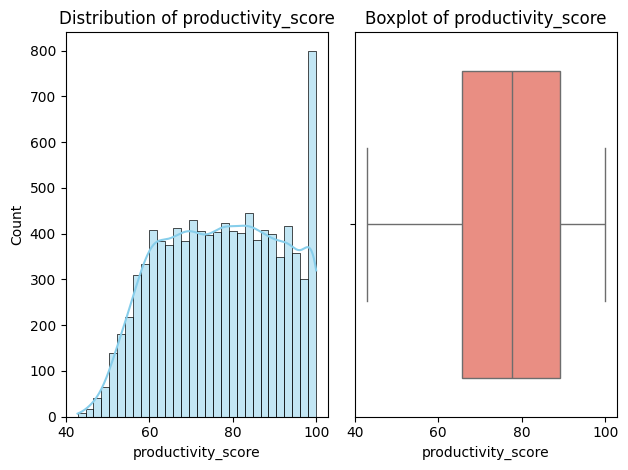

In [ ]:
def interpret_skewness(skew_val):
    if -0.5 <= skew_val <= 0.5:
        return "Approximately symmetric distribution."
    elif 0.5 < skew_val <= 1:
        return "Moderate positive skew (right tail longer). Consider transformation."
    elif skew_val > 1:
        return "Highly positive skew. Transformation likely needed."
    elif -1 <= skew_val < -0.5:
        return "Moderate negative skew (left tail longer). Consider transformation."
    else:  # skew_val < -1
        return "Highly negative skew. Transformation or special handling advised."
#Perform univariate analysis for each numerical feature
numerical_cols = [
    'age',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score',
    'social_support_score',
    'stress_level',
    'productivity_score'
]
for col in numerical_cols:
    print(f"\nVariable numérique: {col}")

    # Summary statistics
    print("\nDescriptive Statistics:")
    print(df[col].describe())

    # Skewness
    skew_val = df[col].skew()
    print(f"\nSkewness: {skew_val:.2f}")
    print(f"\nInterpretation of skewness: {interpret_skewness(skew_val)}")

    # Histogram and KDE plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()



```
Skewness = 0 → The distribution is perfectly symmetric (like a normal distribution).

Skewness > 0 → Positive skew (right-skewed): The right tail is longer or fatter. Most values cluster on the left.

Skewness < 0 → Negative skew (left-skewed): The left tail is longer or fatter. Most values cluster on the right.

```



### 3.2 Variables catégorielles


Variable: gender

Value Counts:
gender
Male                 4557
Female               4457
Non-binary            520
Prefer not to say     466
Name: count, dtype: int64

Percentage Distribution:
gender
Male                 45.57
Female               44.57
Non-binary            5.20
Prefer not to say     4.66
Name: proportion, dtype: float64


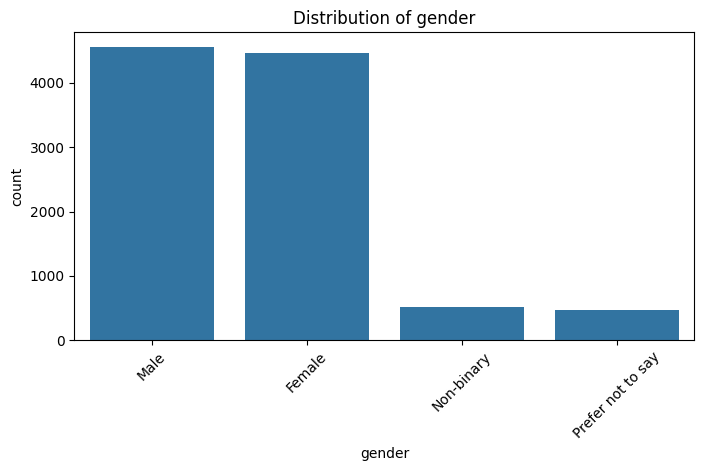


Variable: employment_status

Value Counts:
employment_status
Employed         5868
Student          2043
Self-employed    1045
Unemployed       1044
Name: count, dtype: int64

Percentage Distribution:
employment_status
Employed         58.68
Student          20.43
Self-employed    10.45
Unemployed       10.44
Name: proportion, dtype: float64


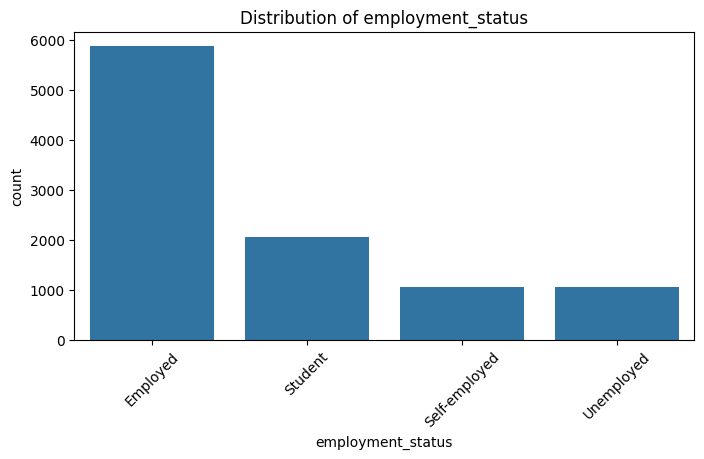


Variable: work_environment

Value Counts:
work_environment
On-site    5044
Remote     3009
Hybrid     1947
Name: count, dtype: int64

Percentage Distribution:
work_environment
On-site    50.44
Remote     30.09
Hybrid     19.47
Name: proportion, dtype: float64


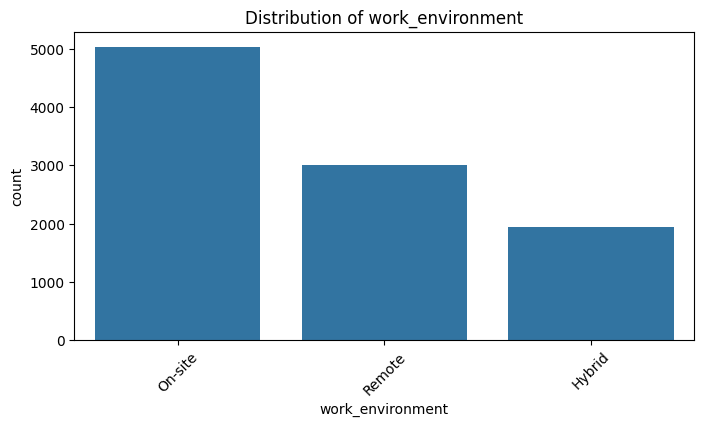


Variable: mental_health_history

Value Counts:
mental_health_history
No     6969
Yes    3031
Name: count, dtype: int64

Percentage Distribution:
mental_health_history
No     69.69
Yes    30.31
Name: proportion, dtype: float64


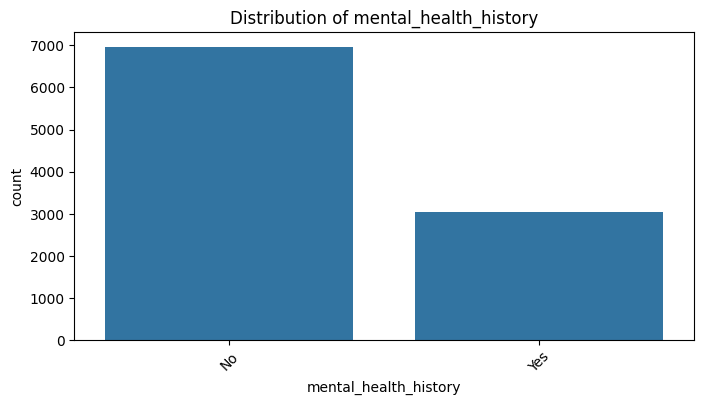


Variable: seeks_treatment

Value Counts:
seeks_treatment
No     6012
Yes    3988
Name: count, dtype: int64

Percentage Distribution:
seeks_treatment
No     60.12
Yes    39.88
Name: proportion, dtype: float64


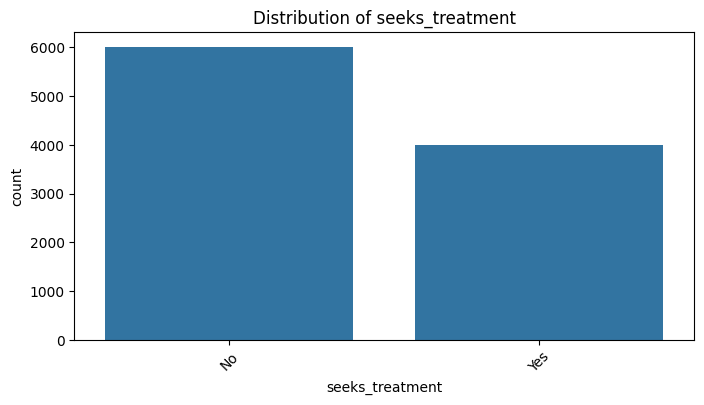


Variable: mental_health_risk

Value Counts:
mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64

Percentage Distribution:
mental_health_risk
Medium    58.92
High      23.69
Low       17.39
Name: proportion, dtype: float64


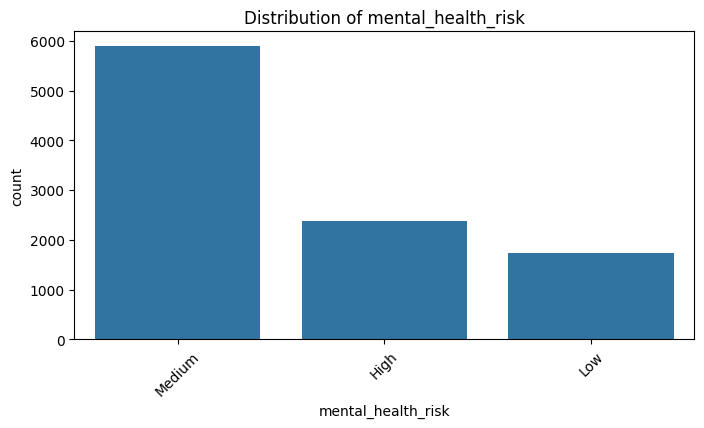


Variable: Gender_clean

Value Counts:
Gender_clean
Male          4557
Female        4457
Non-binary     520
NaN            466
Name: count, dtype: int64

Percentage Distribution:
Gender_clean
Male          45.57
Female        44.57
Non-binary     5.20
NaN            4.66
Name: proportion, dtype: float64


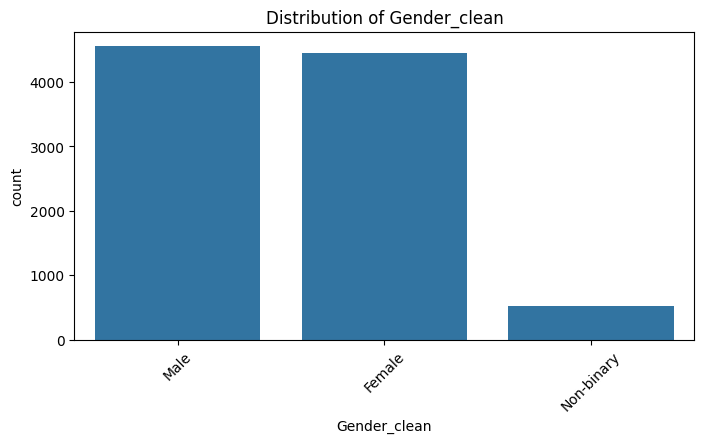

In [ ]:
categorical_cols = [
    'gender',
    'employment_status',
    'work_environment',
    'mental_health_history',
    'seeks_treatment',
    'mental_health_risk',
    'Gender_clean'
]

for col in categorical_cols:
    print(f"\nVariable: {col}")
    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))
    print("\nPercentage Distribution:")
    print(round(df[col].value_counts(normalize=True, dropna=False) * 100, 2))

    # Plot countplot
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

#**Partie de Ijlal Sellak**

## 4. Analyse bivariée

### 4.1 Corrélation entre variables numériques

Objectif : Identifier les corrélations entre variables numériques.





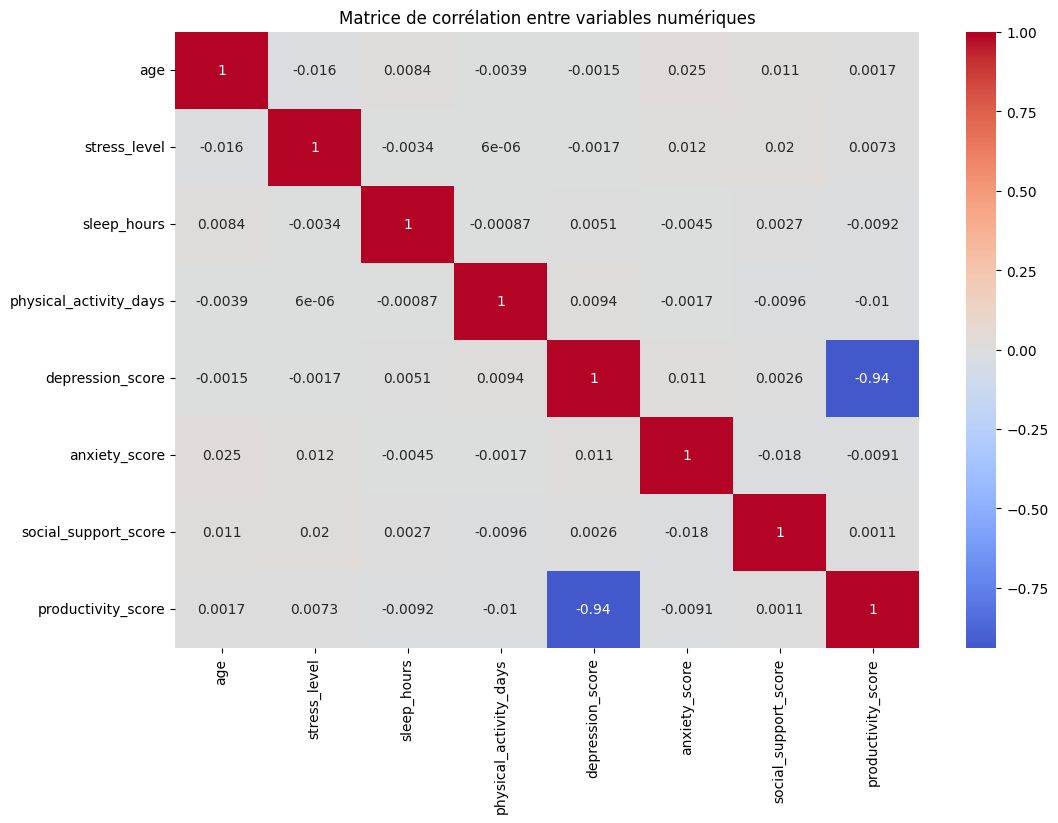

In [ ]:
# Calcul et visualisation de la matrice de corrélation
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation entre variables numériques')
plt.show()

Que signifie chaque valeur de corrélations?

| Valeur de corrélation | Signification                              |
| --------------------- | ------------------------------------------ |
| +1.0                  | Corrélation linéaire **parfaite positive** |
| 0.0                   | **Aucune corrélation linéaire**            |
| -1.0                  | Corrélation linéaire **parfaite négative** |
| > 0.7                 | Corrélation forte **positive**             |
| < -0.7                | Corrélation forte **négative**             |
| Environ 0.3 à 0.6     | Corrélation modérée                        |


Résultats :

Matrice colorée où les valeurs proches de 1 (bleu) indiquent une forte corrélation positive.

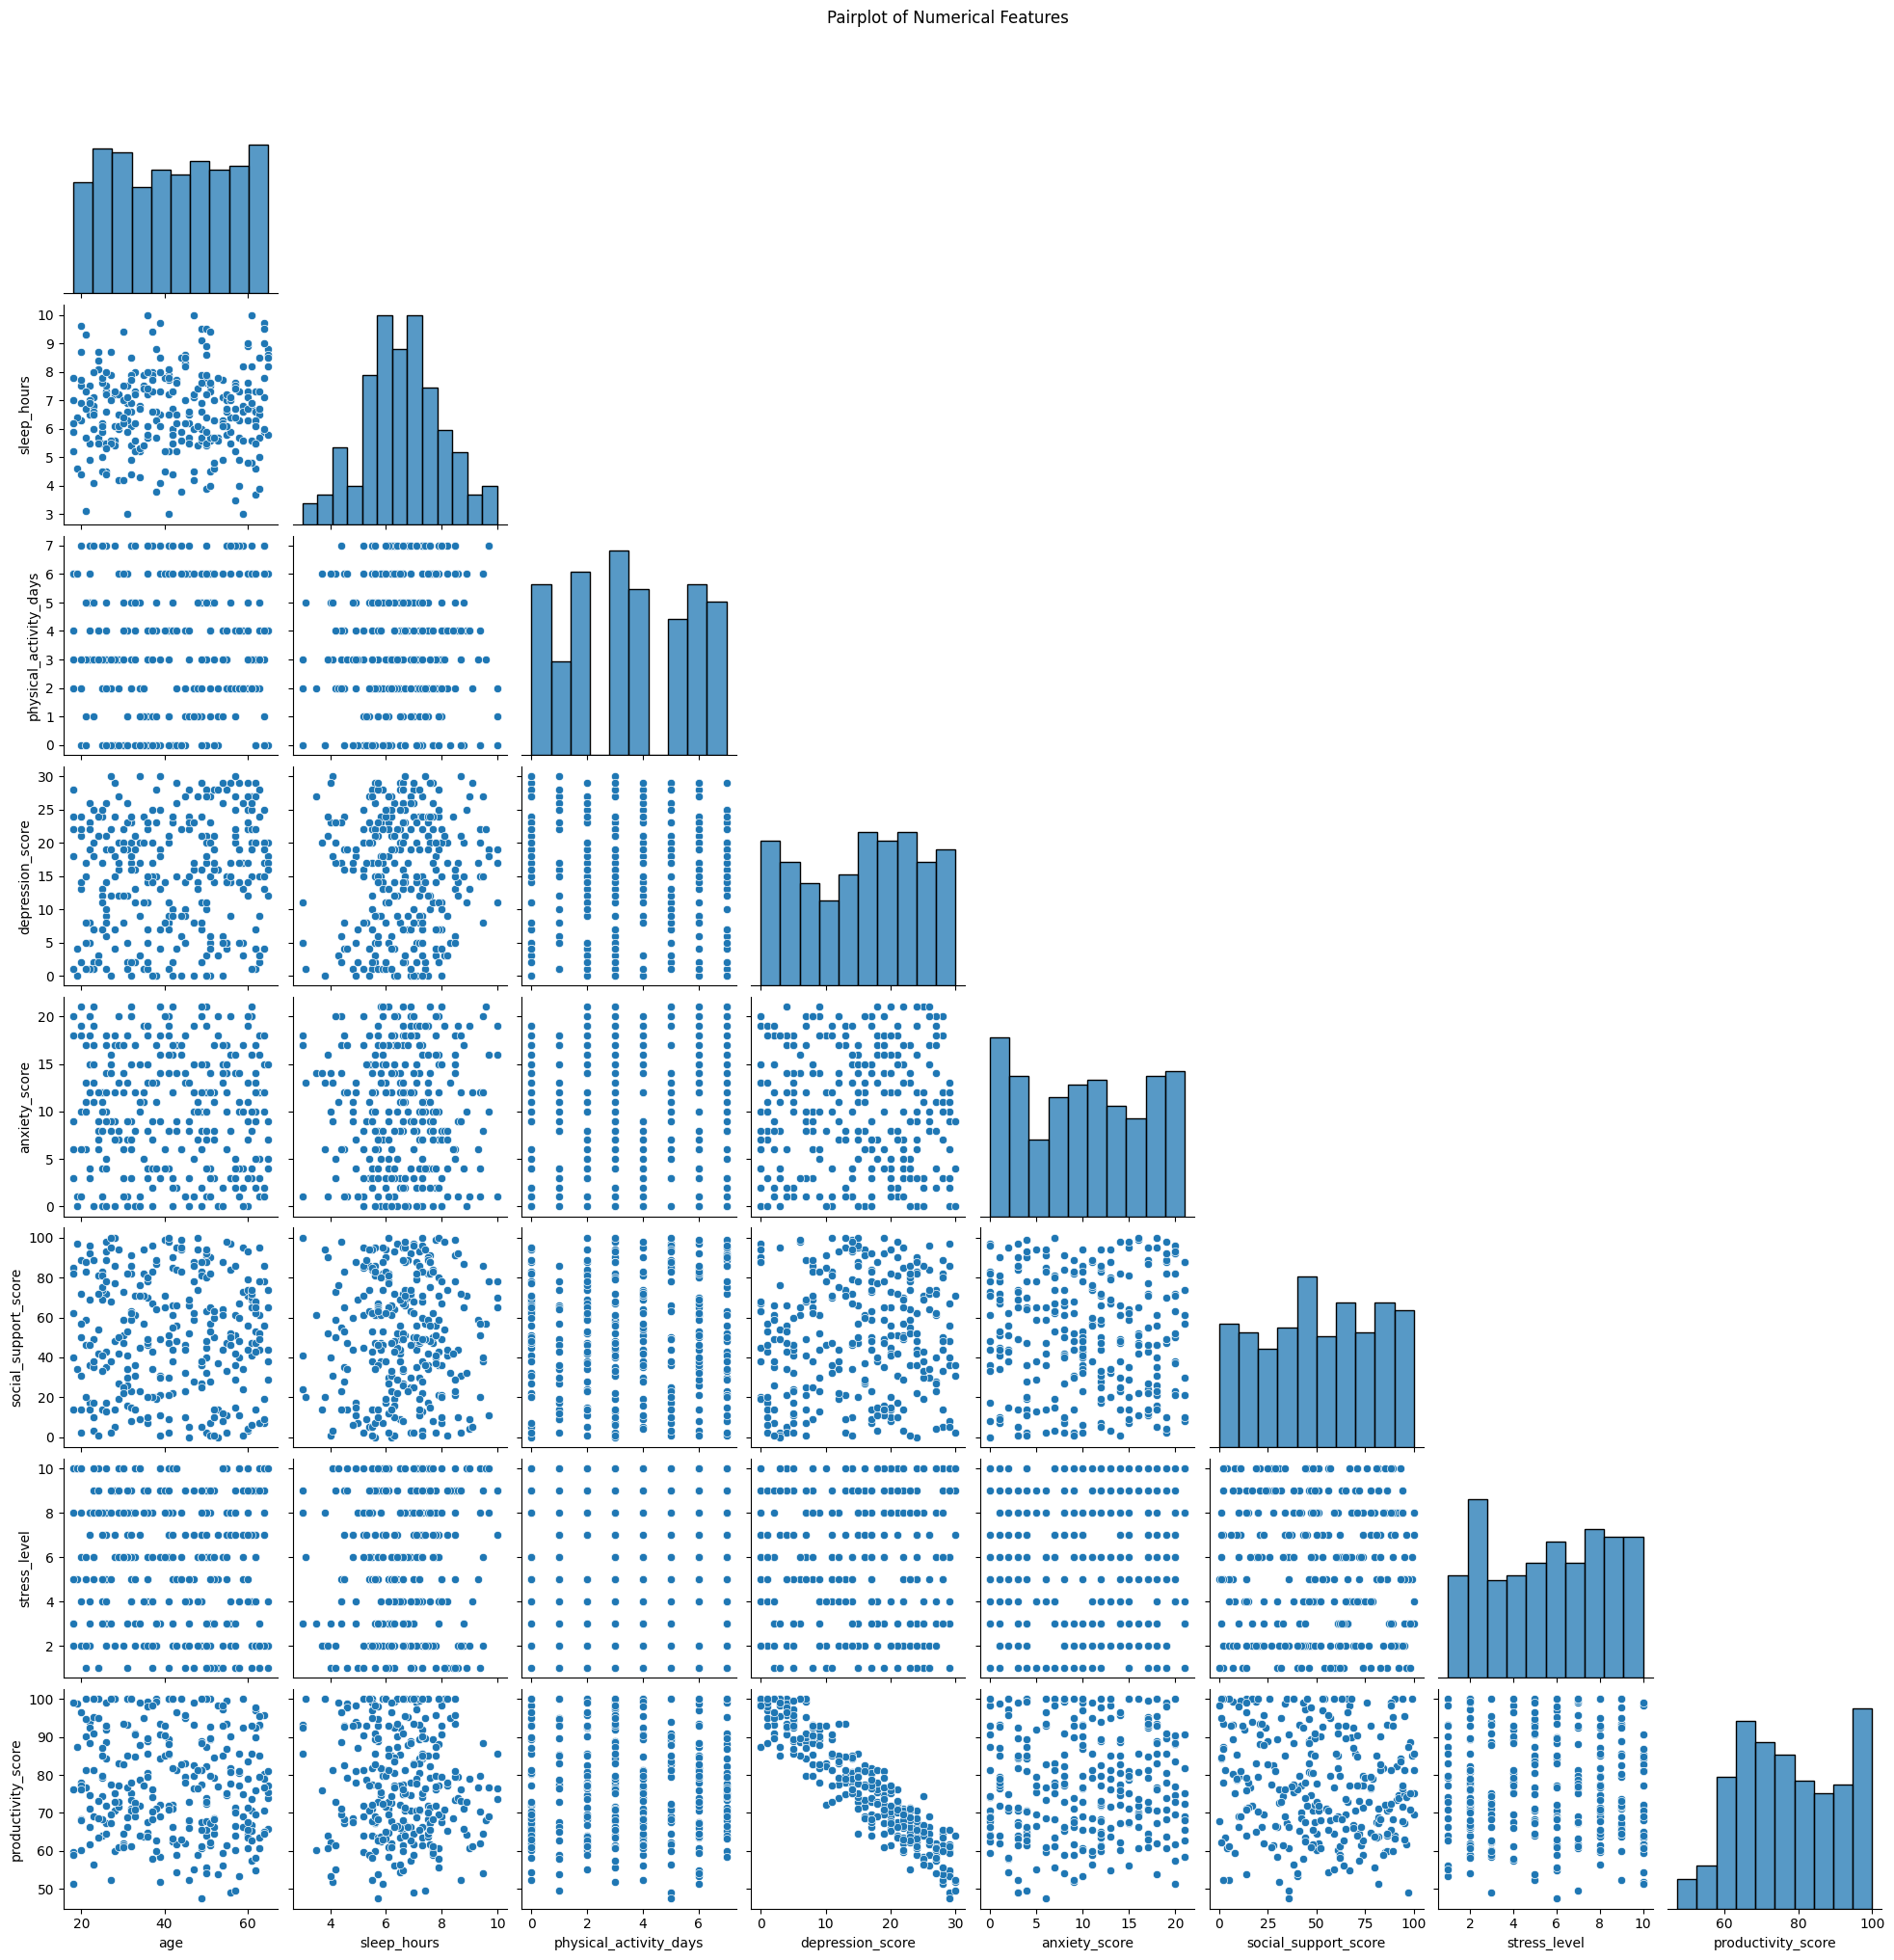

In [ ]:
#avec pairplot
sns.pairplot(df[numerical_cols].sample(300), corner=True)
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()


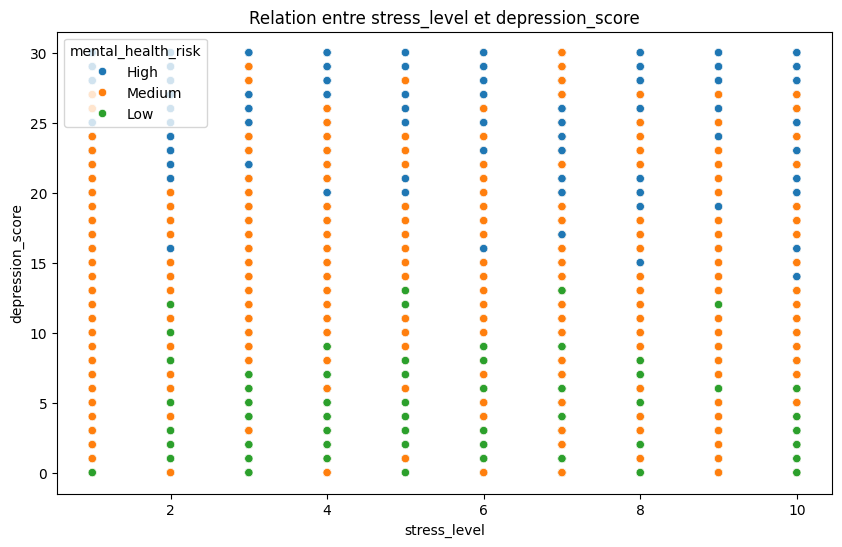

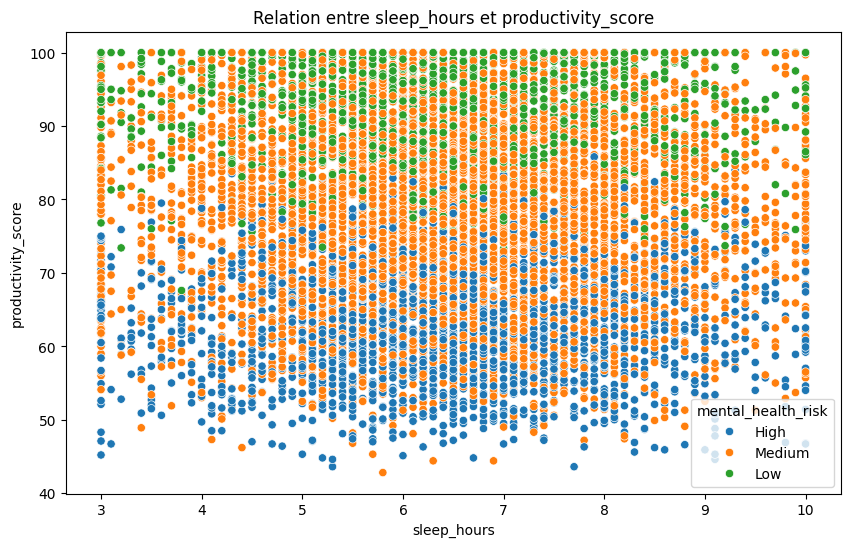

In [ ]:
#exemples de relations:

# Relation entre stress_level et depression_score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='stress_level', y='depression_score', hue='mental_health_risk', data=df)
plt.title('Relation entre stress_level et depression_score')
plt.show()




# Relation entre sleep_hours et productivity_score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sleep_hours', y='productivity_score', hue='mental_health_risk', data=df)
plt.title('Relation entre sleep_hours et productivity_score')
plt.show()

###4-2 Relation entre deux variables **catégorielles**

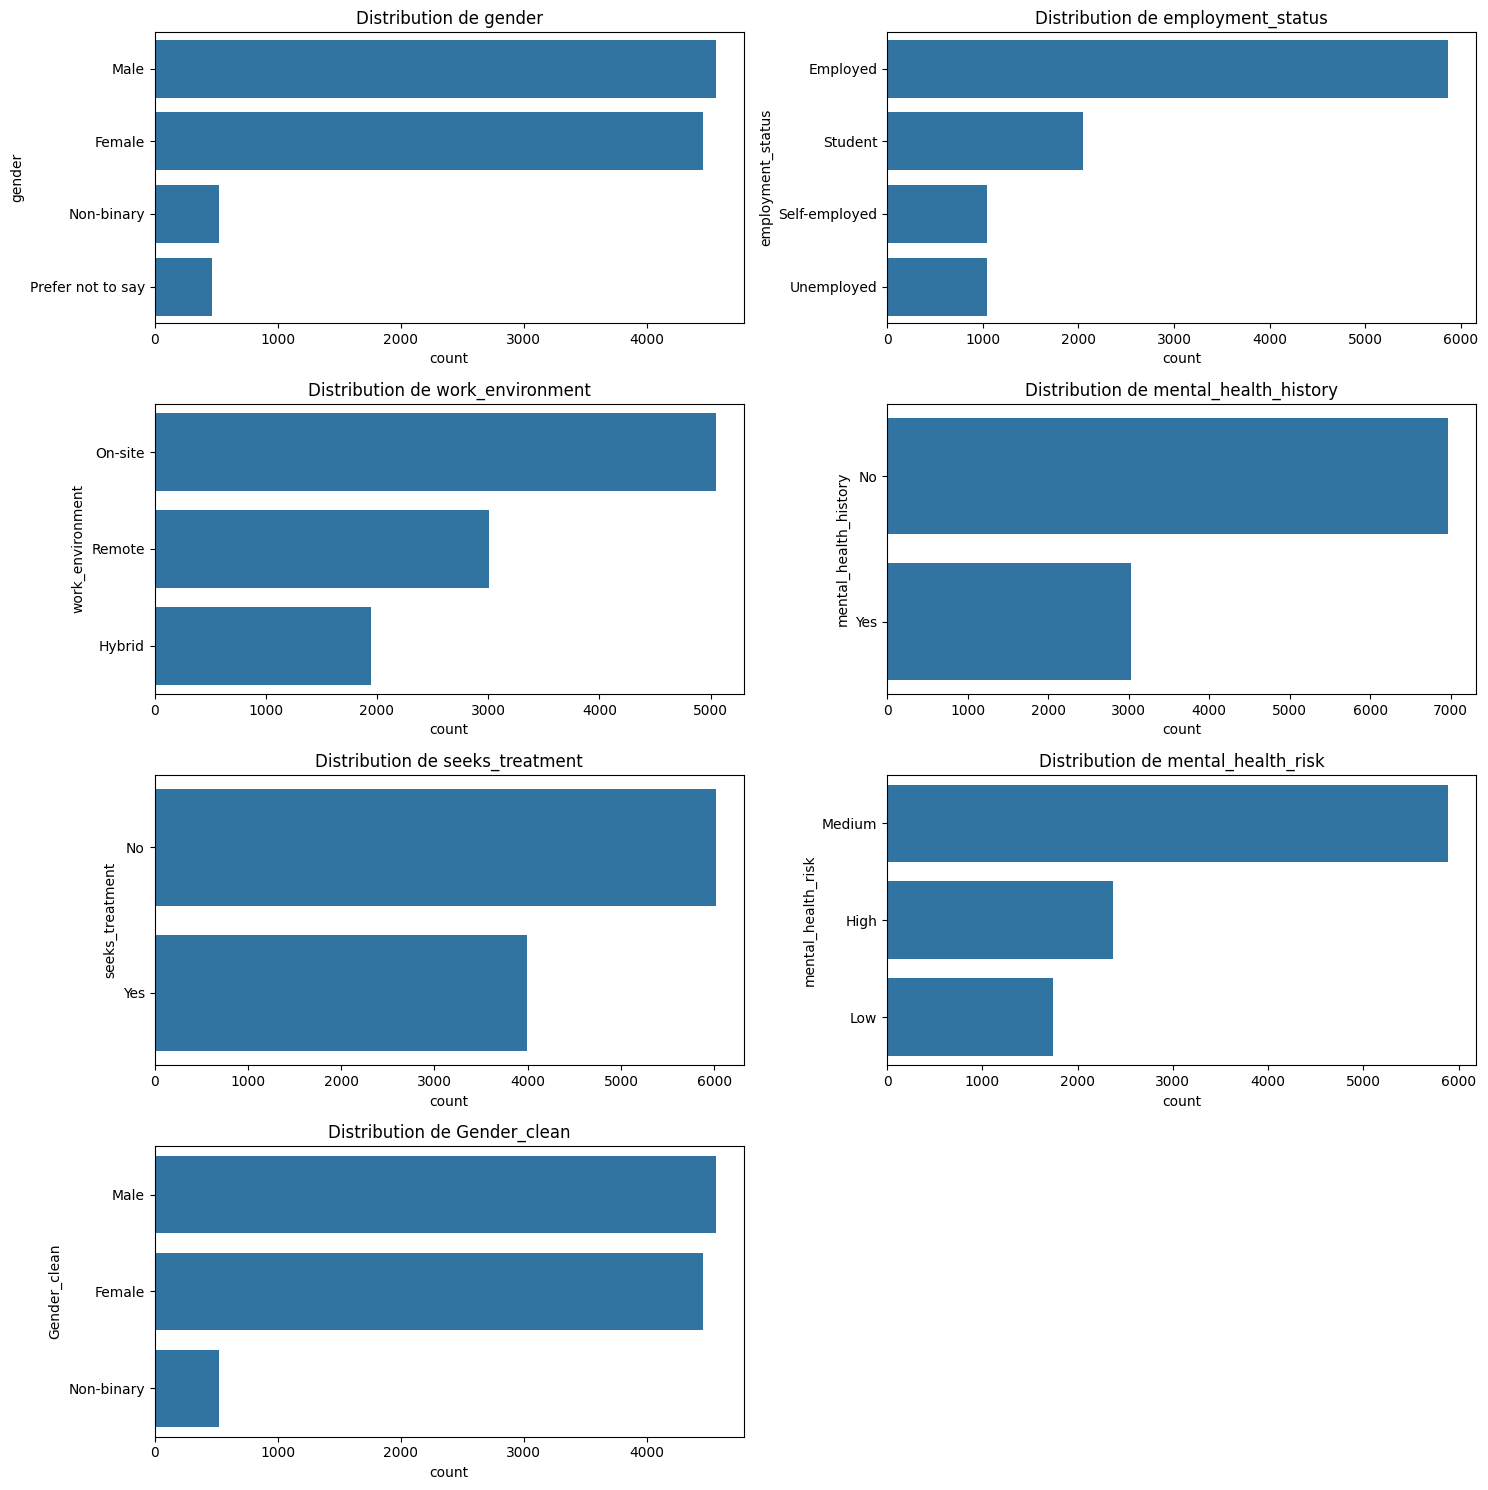

In [ ]:
# Sélection des colonnes catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns

# Visualisation des distributions
plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i+1)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()


In [ ]:
# 📌 Test du Chi² entre variables catégorielles
from scipy.stats import chi2_contingency
import pandas as pd

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):
        table = pd.crosstab(df[categorical_cols[i]], df[categorical_cols[j]])
        chi2, p, dof, expected = chi2_contingency(table)
        print(f"🔎 Chi² test entre {categorical_cols[i]} et {categorical_cols[j]} :")
        print(f"    Statistique = {chi2:.2f}, p-value = {p:.4f}")
        print("")


🔎 Chi² test entre gender et employment_status :
    Statistique = 6.79, p-value = 0.6594

🔎 Chi² test entre gender et work_environment :
    Statistique = 4.89, p-value = 0.5586

🔎 Chi² test entre gender et mental_health_history :
    Statistique = 2.26, p-value = 0.5198

🔎 Chi² test entre gender et seeks_treatment :
    Statistique = 4.11, p-value = 0.2499

🔎 Chi² test entre gender et mental_health_risk :
    Statistique = 3.26, p-value = 0.7755

🔎 Chi² test entre gender et Gender_clean :
    Statistique = 19068.00, p-value = 0.0000

🔎 Chi² test entre employment_status et work_environment :
    Statistique = 6.45, p-value = 0.3747

🔎 Chi² test entre employment_status et mental_health_history :
    Statistique = 0.75, p-value = 0.8620

🔎 Chi² test entre employment_status et seeks_treatment :
    Statistique = 1.64, p-value = 0.6507

🔎 Chi² test entre employment_status et mental_health_risk :
    Statistique = 9.23, p-value = 0.1609

🔎 Chi² test entre employment_status et Gender_clean :

 Comment interpréter la p-value?

Si p < 0.05 :  rejet de H₀, les deux variables sont dépendantes ⇒ il existe une relation significative.

Si p ≥ 0.05 : on accepte H₀, les variables sont indépendantes ⇒ pas de lien détecté.



Variables avec une dépendance statistiquement significative (p-value < 0.05)

| Variables Comparées                          | Statistique du test | p-value | Interprétation                                                                  |
| -------------------------------------------- | ------------------- | ------- | ------------------------------------------------------------------------------- |
| **gender vs Gender\_clean**                  | 19068.00            | 0.0000  | ✅ Très forte dépendance logique (probablement redondance ou transformation).    |
| **seeks\_treatment vs mental\_health\_risk** | 10.27               | 0.0059  | ✅ Relation significative : la perception du risque influence la demande d'aide. |


Variables sans relation significative (p-value ≥ 0.05)


**gender ne semble pas influencer significativement :**

-le statut d’emploi,

-l’environnement de travail,

-l’historique de santé mentale,

-ni la demande de traitement.

Le statut d’emploi n’est pas significativement relié aux autres variables.:




**Heatmap des fréquences relatives**:




/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


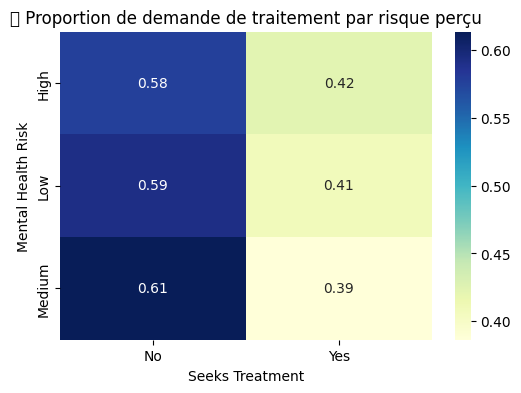

In [ ]:
# Table de contingence normalisée
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
contingency = pd.crosstab(df['mental_health_risk'], df['seeks_treatment'], normalize='index')

plt.figure(figsize=(6, 4))
sns.heatmap(contingency, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("📌 Proportion de demande de traitement par risque perçu")
plt.xlabel("Seeks Treatment")
plt.ylabel("Mental Health Risk")
plt.show()



Ce que cette heatmap t’apporte :
Elle montre pour chaque catégorie de mental_health_risk la proportion (%) de personnes qui cherchent un traitement.

C’est très utile pour voir l’évolution des comportements selon la perception du risque.

### 4-3 Croisement entre variables catégorielles et numériques





1.   Est-ce que le niveau de stress varie selon le genre ?
2.   Y a-t-il une différence de score de bien-être entre ceux qui cherchent un traitement ou non ?
3.   Les personnes ayant un historique de santé mentale ont-elles des valeurs numériques différentes ?




<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


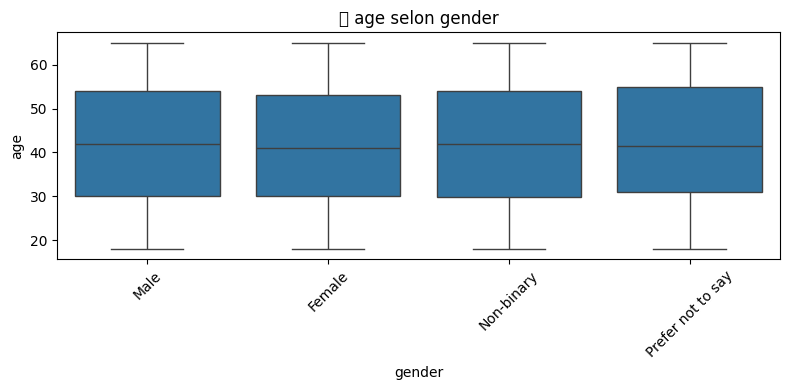

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


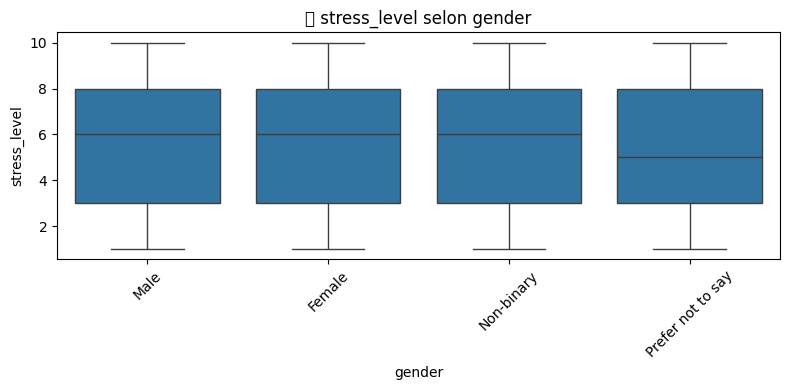

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


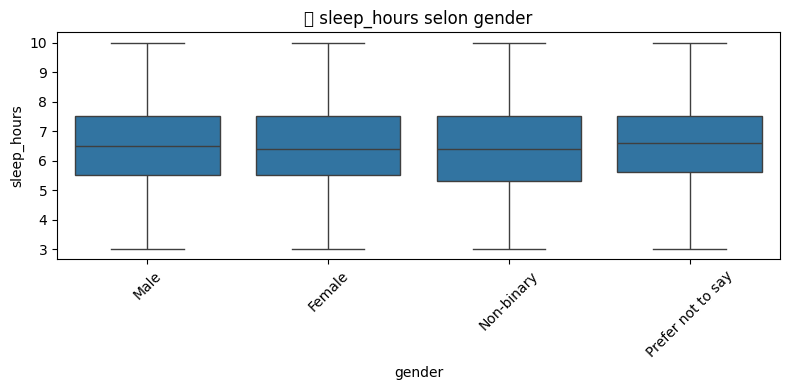

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


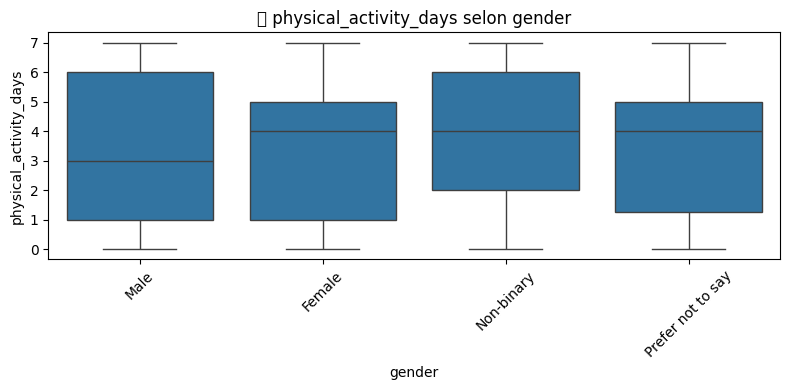

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


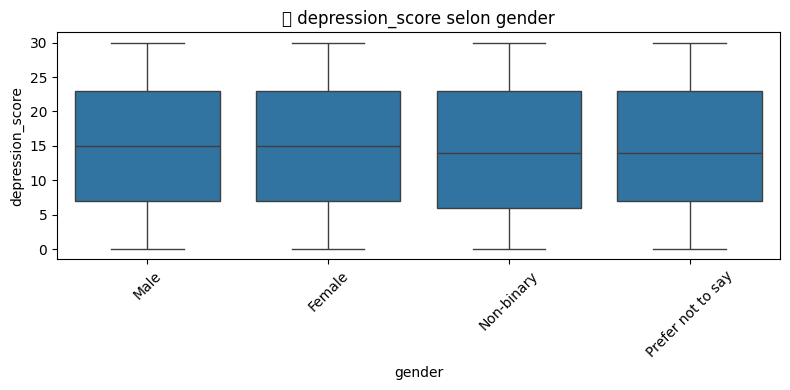

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


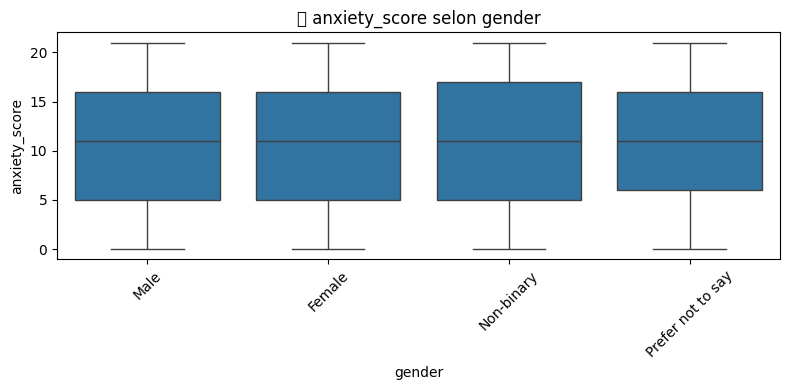

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


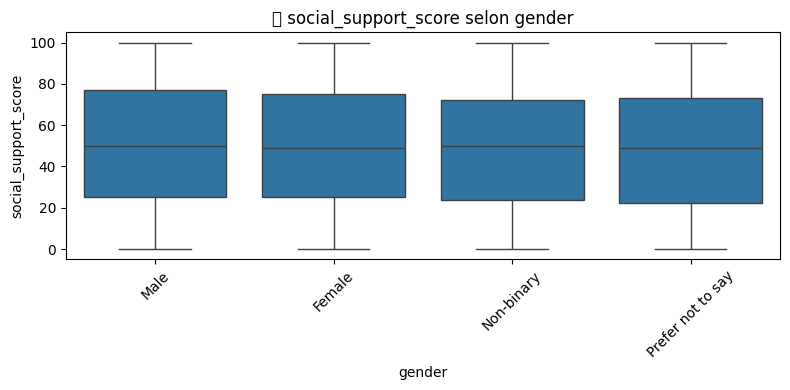

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


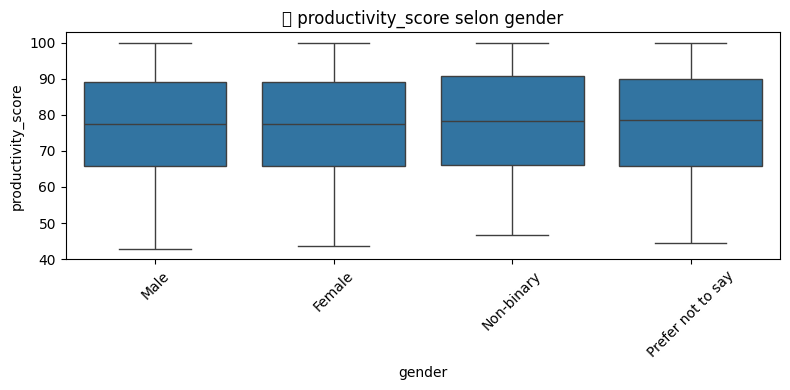

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


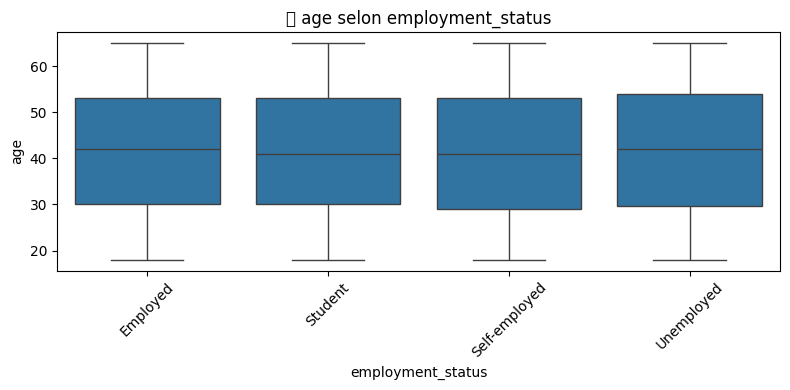

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


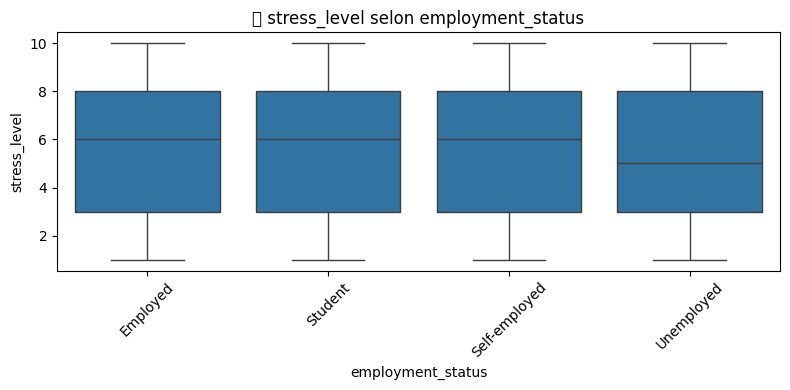

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


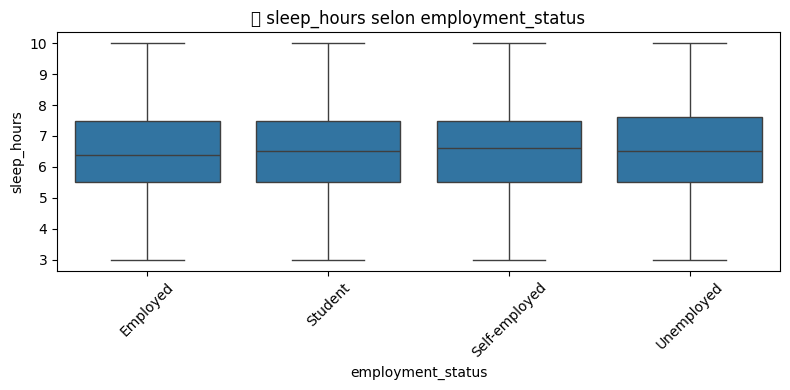

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


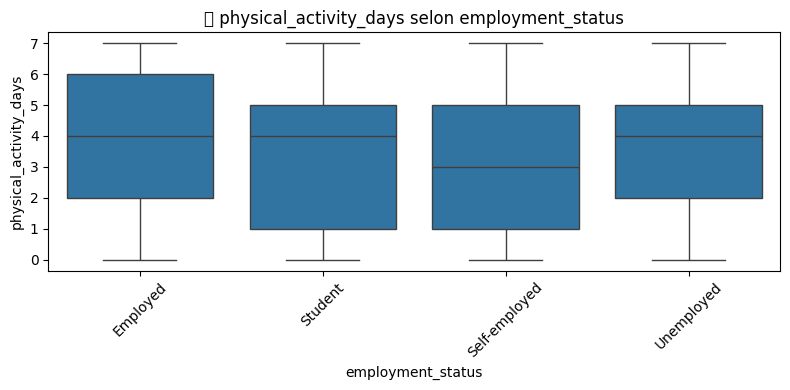

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


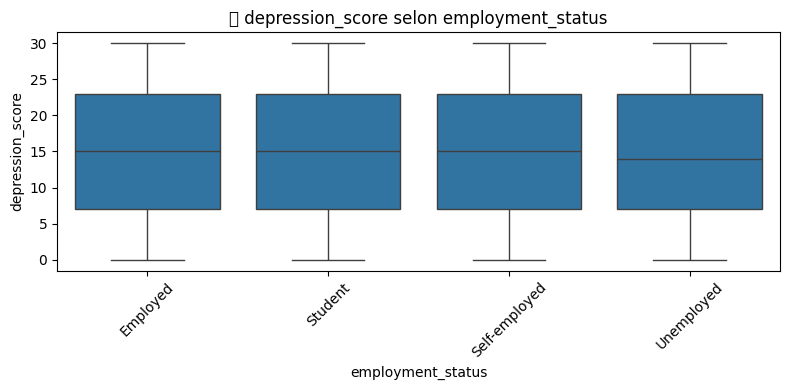

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


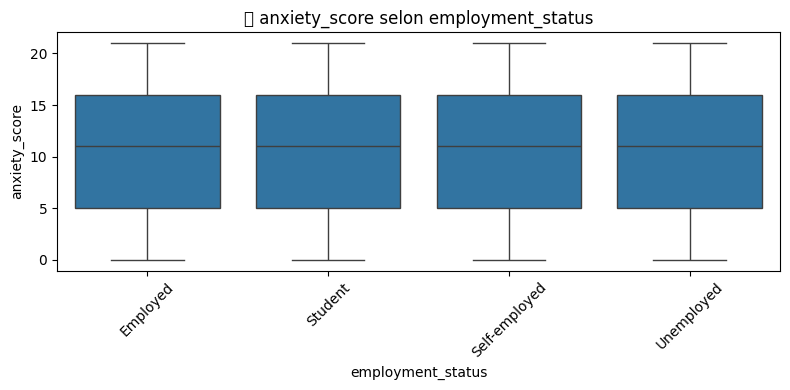

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


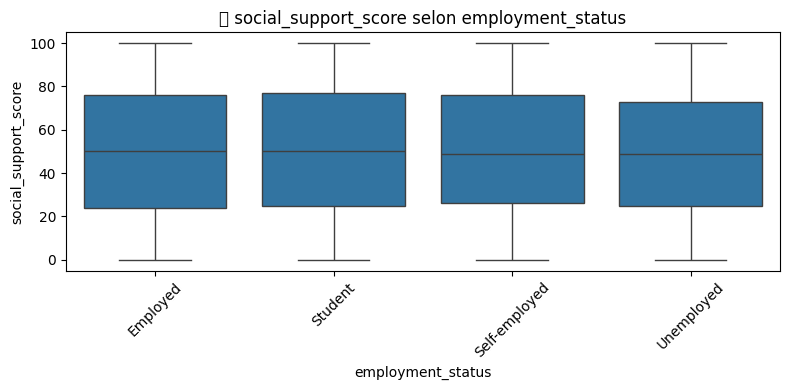

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


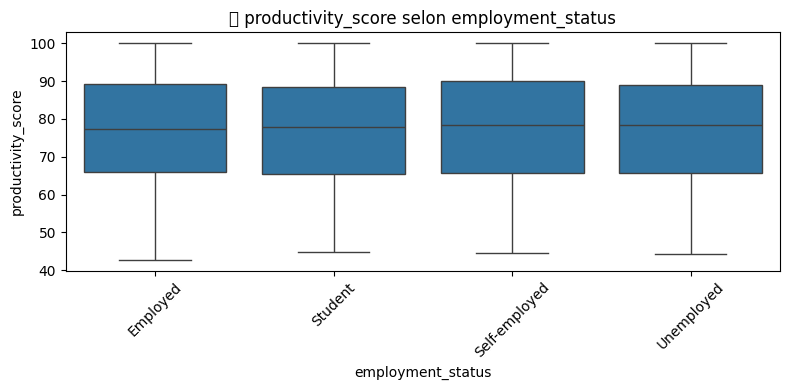

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


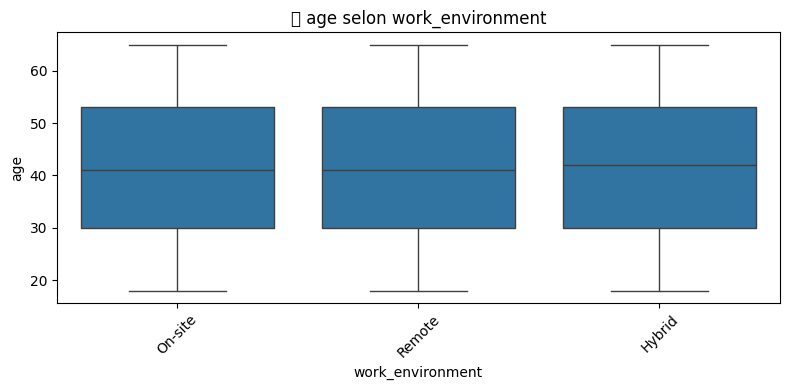

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


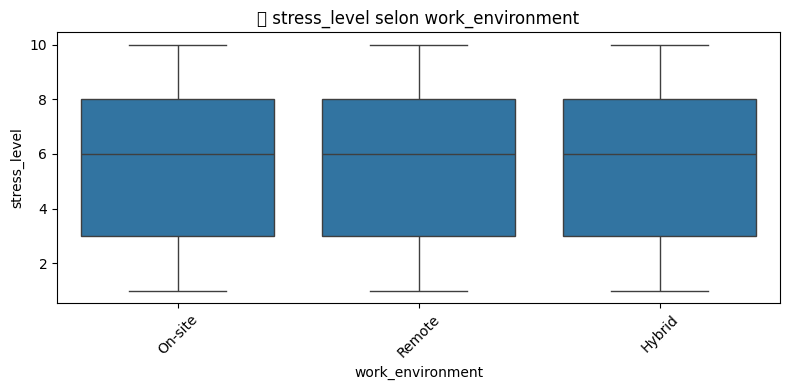

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


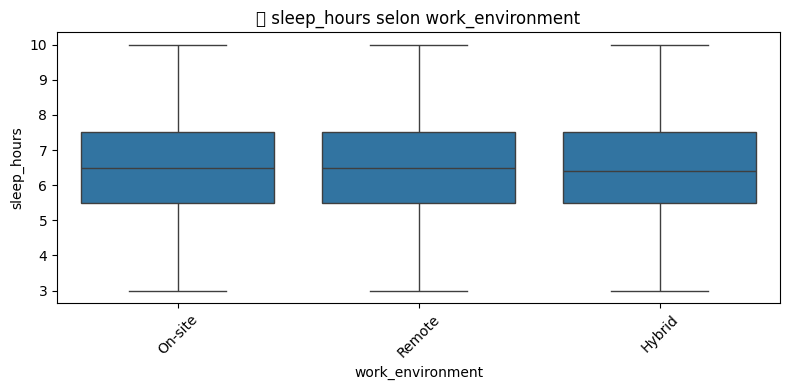

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


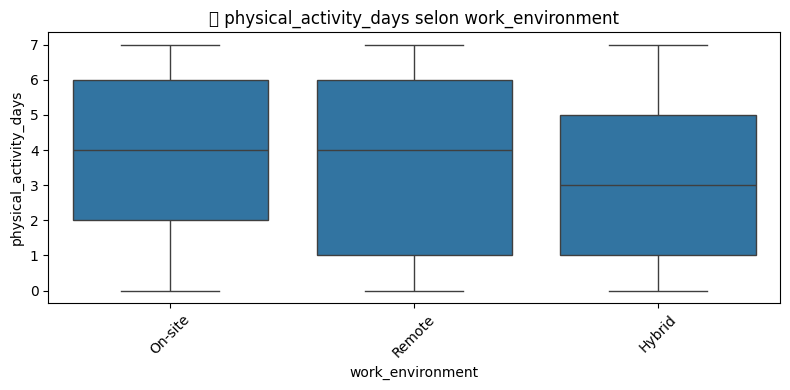

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


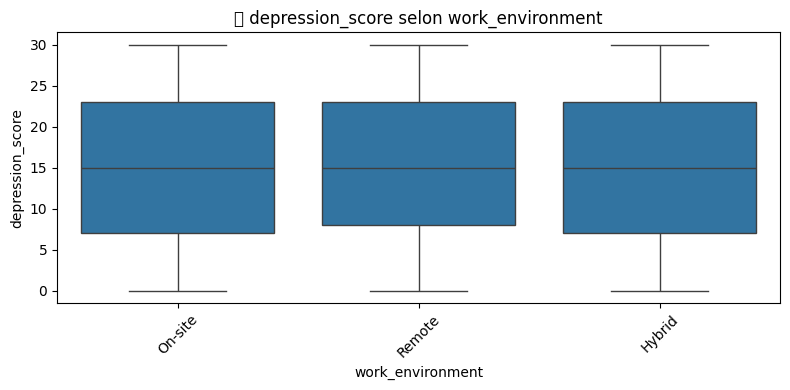

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


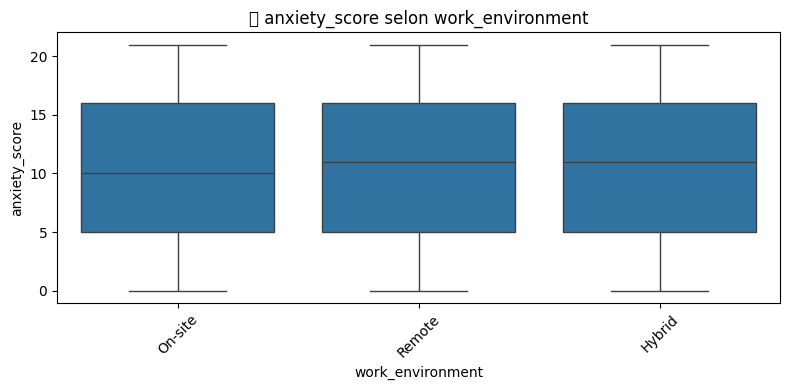

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


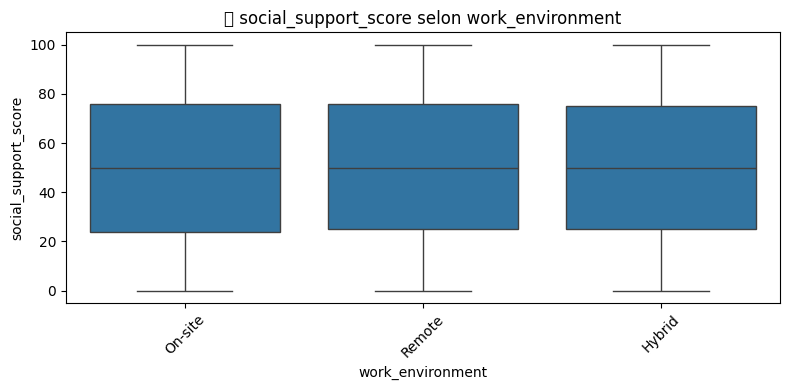

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


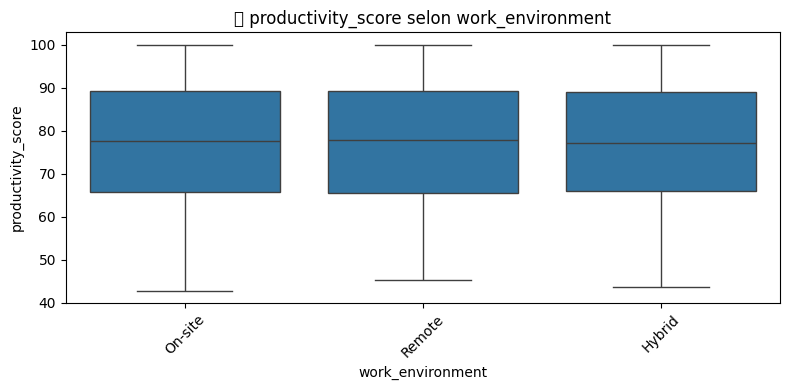

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


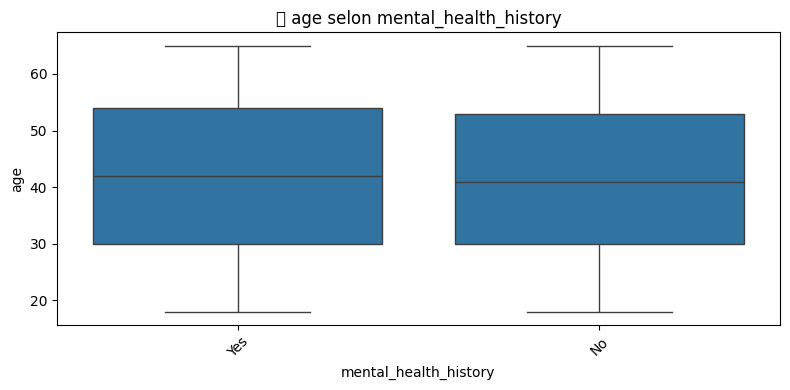

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


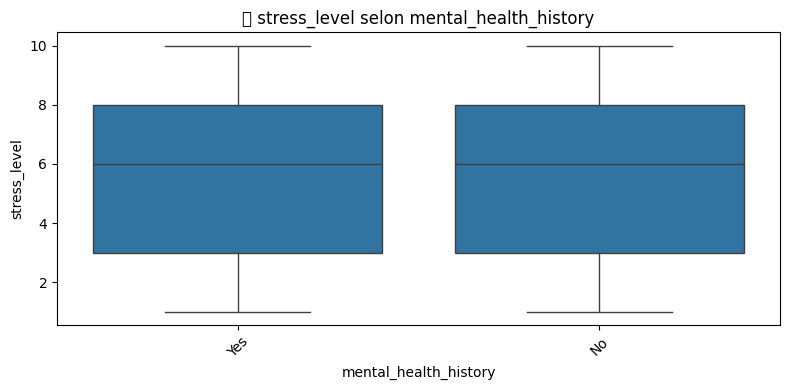

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


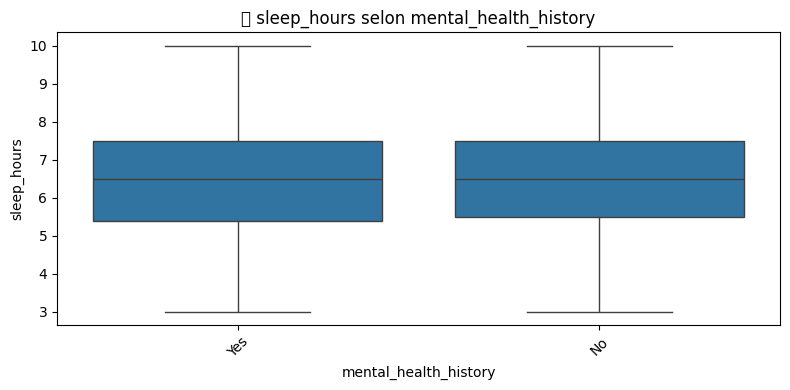

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


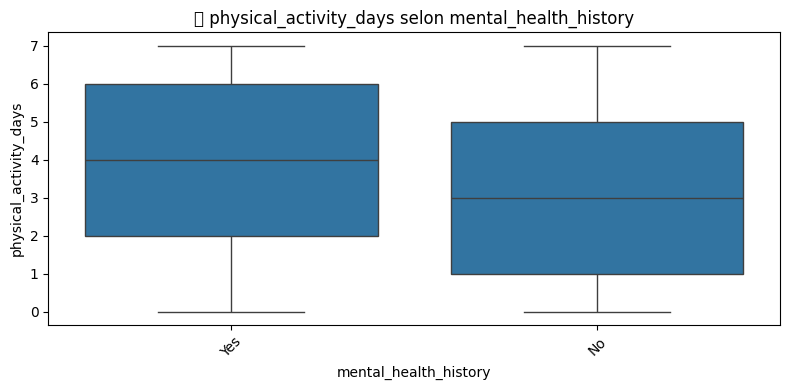

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


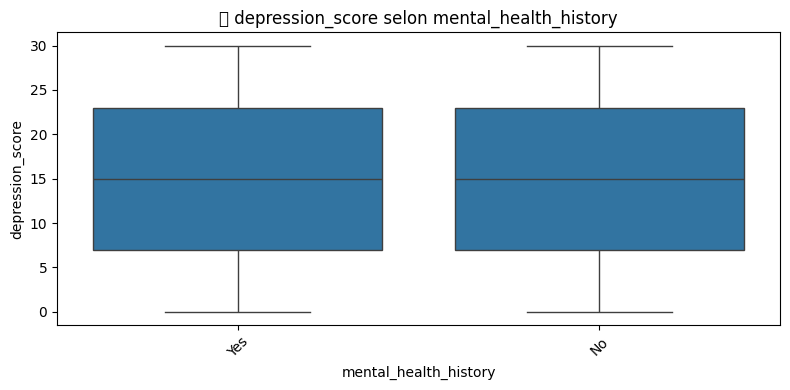

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


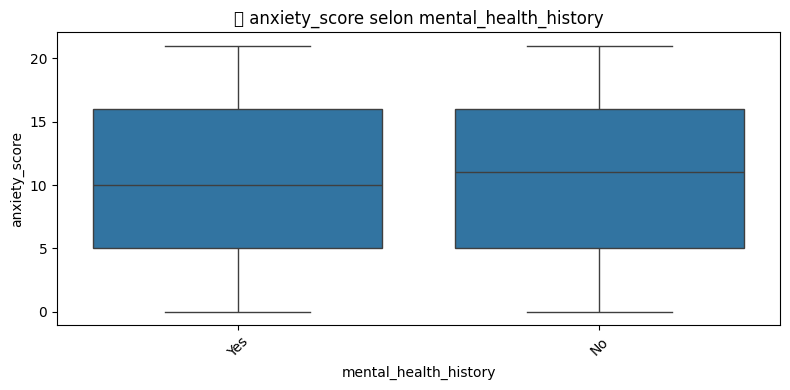

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


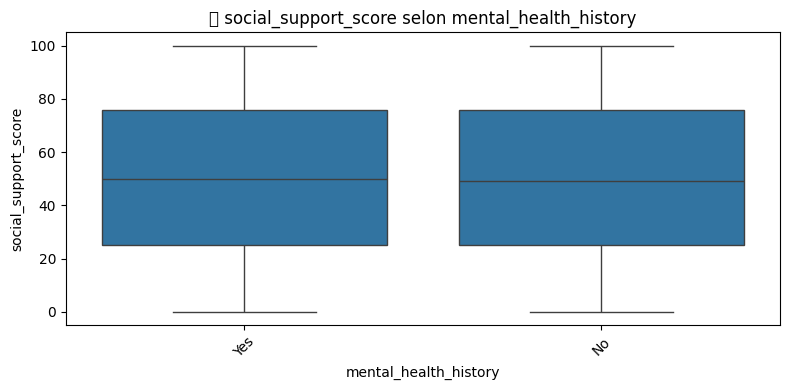

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


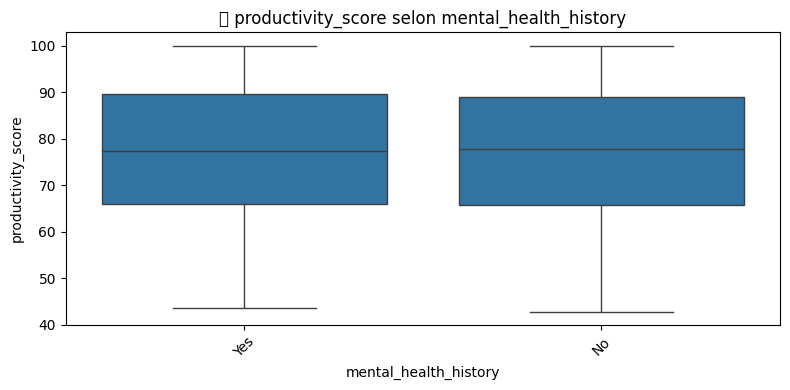

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


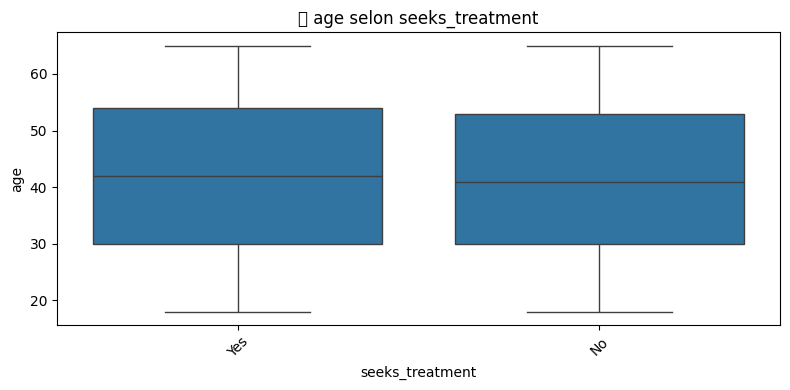

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


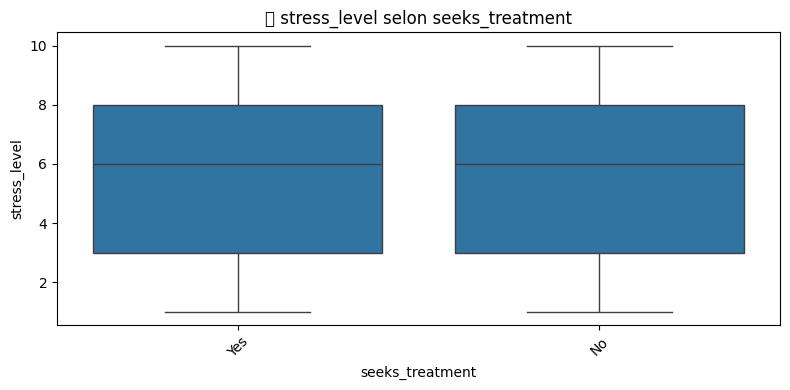

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


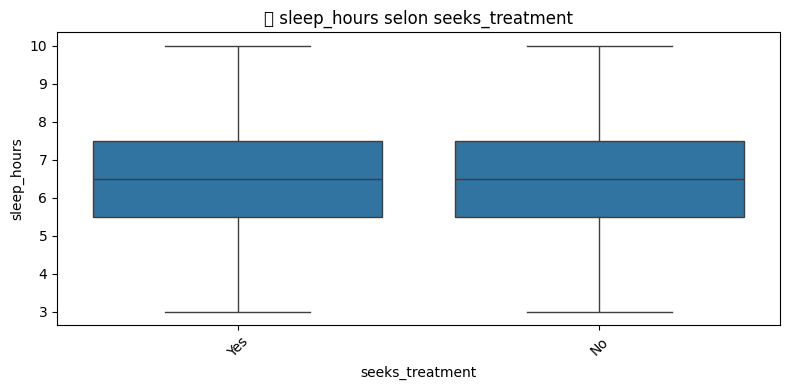

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


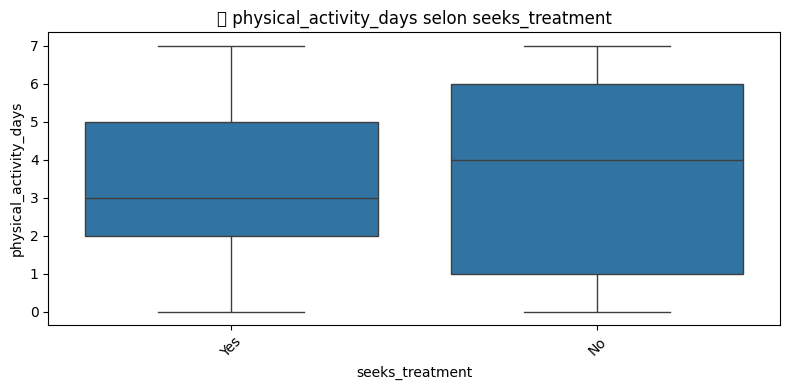

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


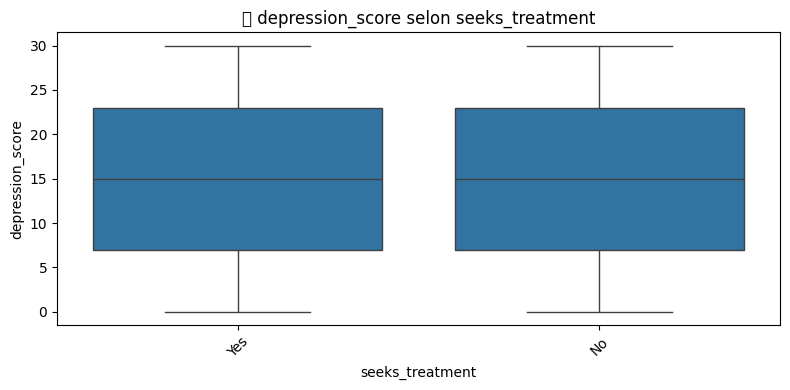

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


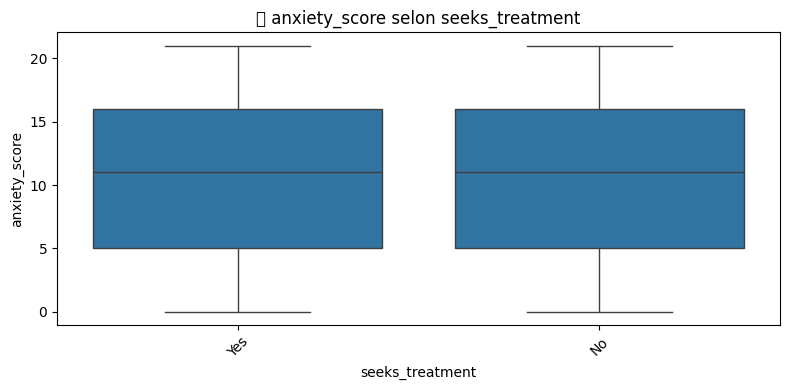

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


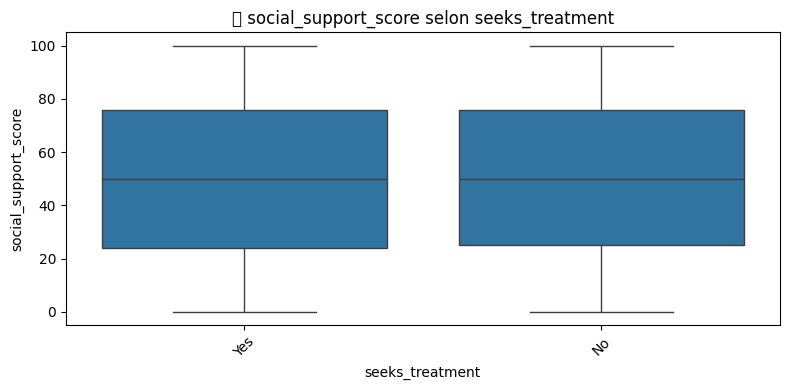

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


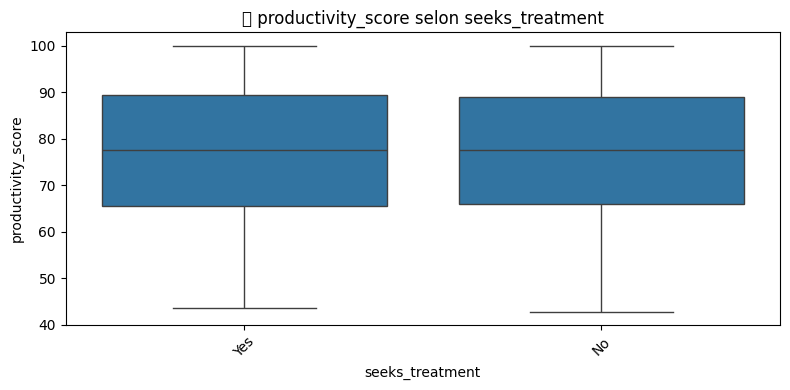

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


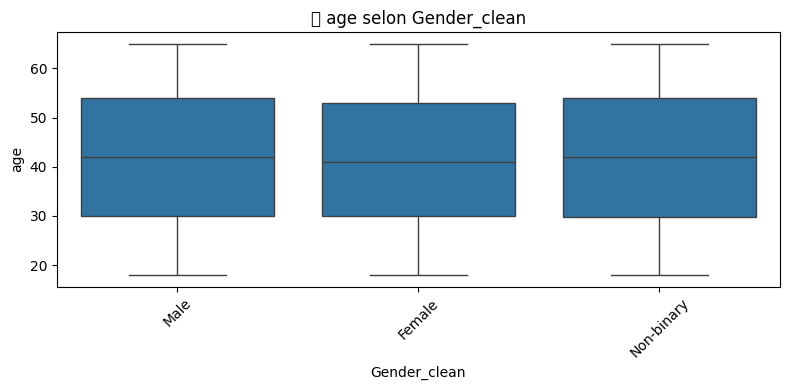

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


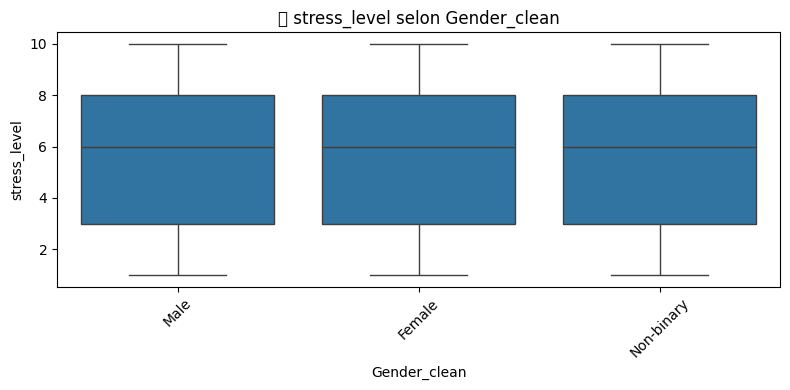

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


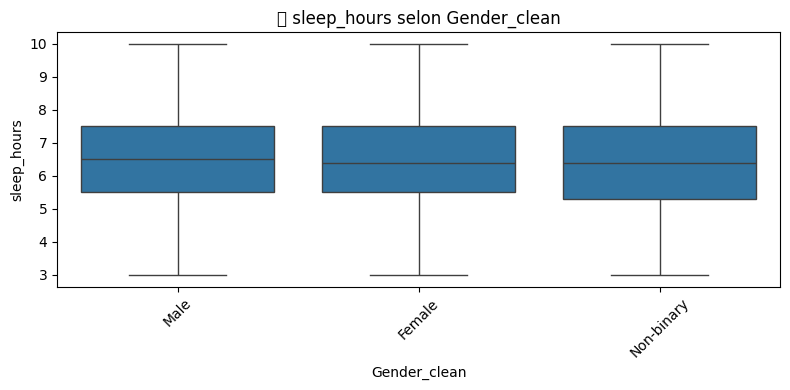

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


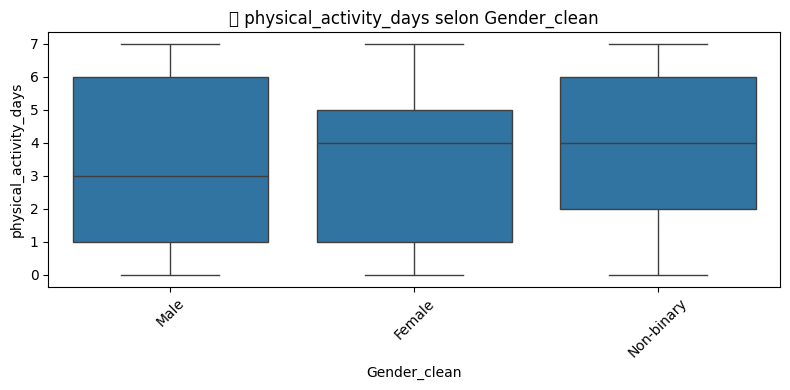

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


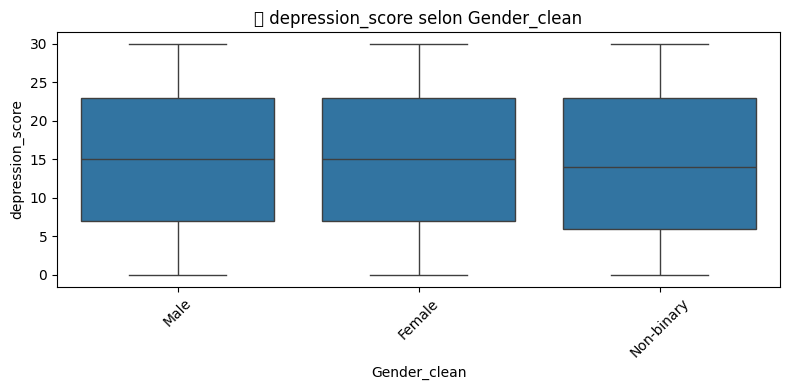

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


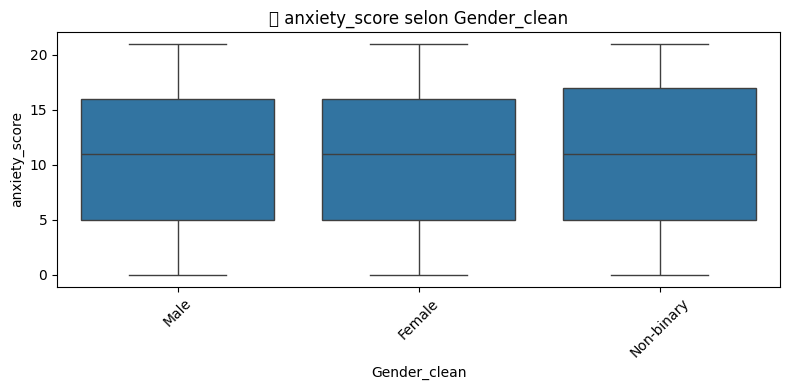

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


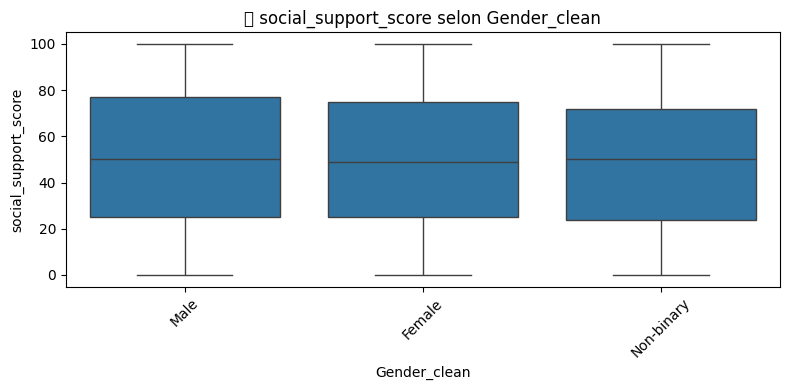

<ipython-input-96-38f0d6ce5ccb>:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


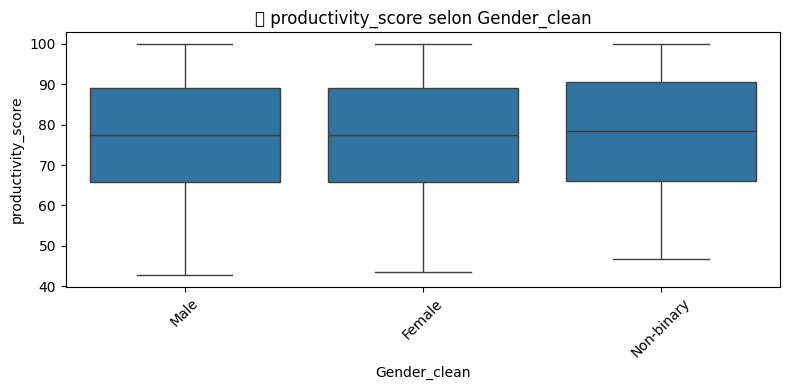

In [ ]:
# Boxplots pour observer les effets des variables catégorielles sur les variables numériques
categorical_cols = ['gender', 'employment_status', 'work_environment', 'mental_health_history', 'seeks_treatment','Gender_clean']
for cat_col in categorical_cols:
    for num_col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=cat_col, y=num_col, data=df)
        plt.title(f"🎯 {num_col} selon {cat_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


Résultats :

Boîtes à moustaches montrant que les High risk ont des scores de dépression plus élevés

## 5. Analyse multivariée

Étape 1 : Segmentation des données (Clustering Exploratoire)

In [ ]:
#Créer des groupes homogènes d’individus (appelés clusters) en fonction
# de leurs données numériques (ex. stress, anxiété, productivité…)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sélection et normalisation des variables numériques
X_cluster = df[numeric_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# KMeans avec 3 clusters (modifiable selon l'analyse de l'inertie)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajout des clusters dans le DataFrame
df_clustered = df.loc[X_cluster.index].copy()
df_clustered['cluster'] = clusters

# Taille des clusters
df_clustered['cluster'].value_counts()



,count
cluster,
0,4289
2,2870
1,2841


Étape 2 : Réduction de dimension (Analyse en Composantes Principales - PCA)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


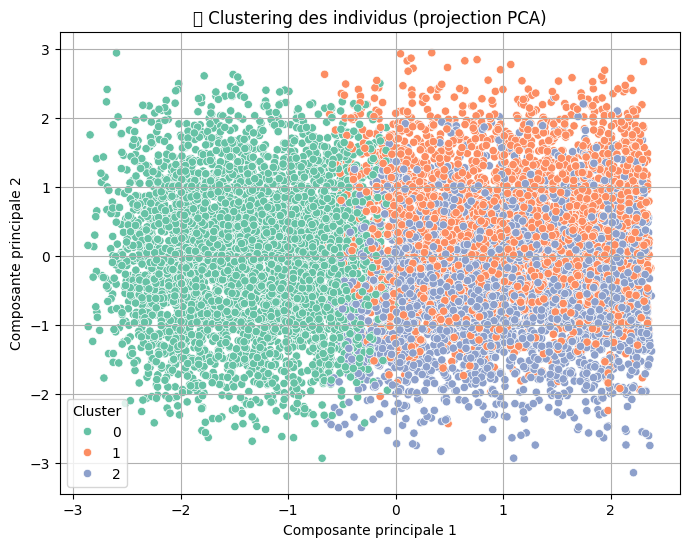

In [ ]:
from sklearn.decomposition import PCA

# PCA pour réduire les dimensions à 2 composantes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisation des clusters dans l’espace PCA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("📊 Clustering des individus (projection PCA)")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


 Étape 3 : Visualisation multidimensionnelle
((A) Visualisation 3D des clusters dans PCA 3D=)



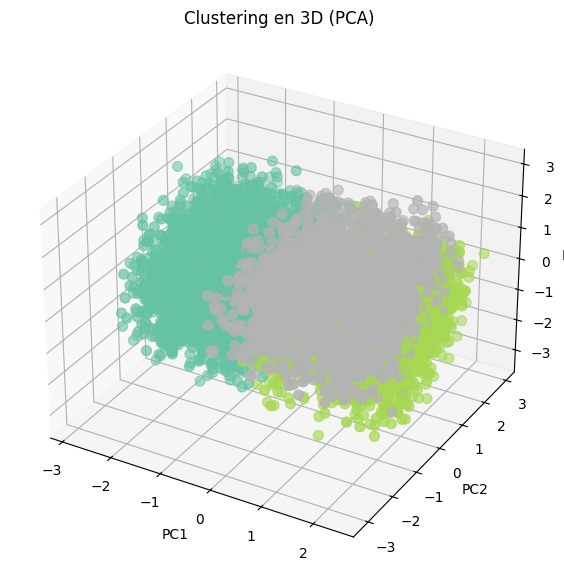

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=clusters, cmap='Set2', s=50)
ax.set_title("Clustering en 3D (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()


(B) Faceting avec Seaborn (clusters vs variables)

---



---



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


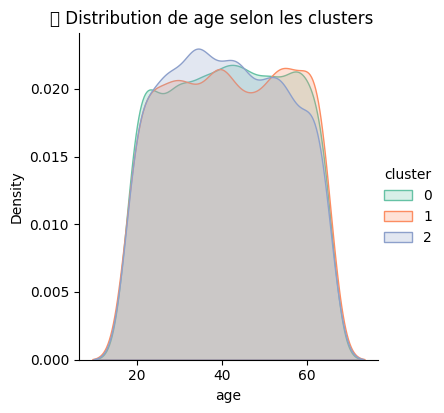

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


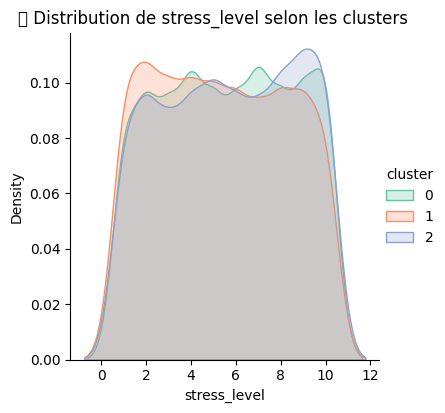

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


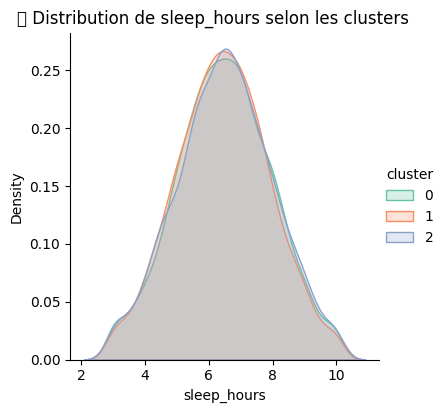

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


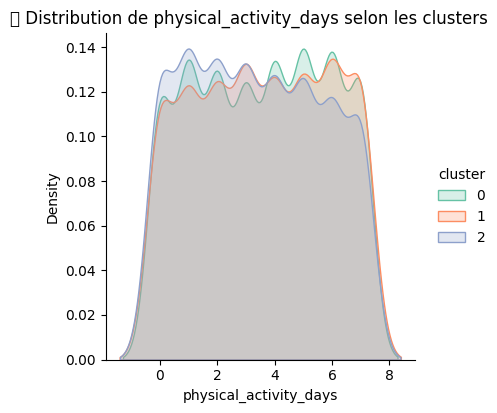

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


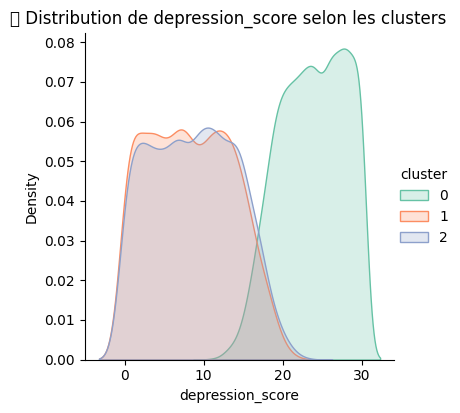

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


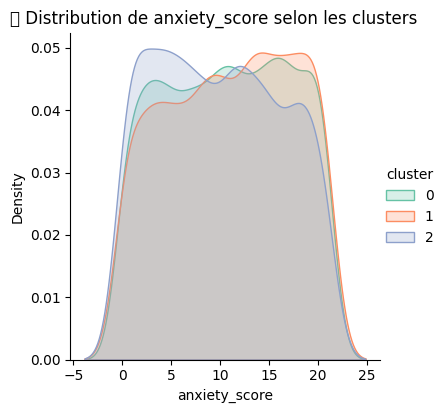

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


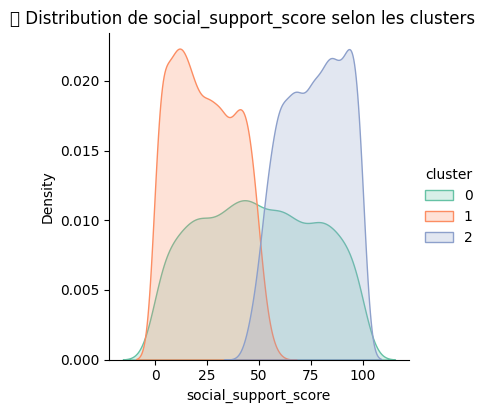

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


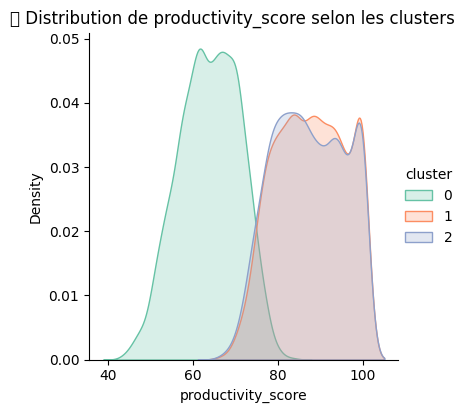

In [ ]:
# Faceting : visualisation des distributions selon les clusters
for col in numeric_cols:
    g = sns.FacetGrid(df_clustered, hue="cluster", palette="Set2", height=4)
    g.map(sns.kdeplot, col, fill=True).add_legend()
    g.fig.suptitle(f"📈 Distribution de {col} selon les clusters", y=1.02)
    plt.show()


Étape 4 : Détection de relations complexes et interactions

 (A) Interactions entre variables numériques et le cluster

In [ ]:
# Moyennes des variables numériques par cluster
cluster_means = df_clustered.groupby("cluster")[numeric_cols].mean()
print("📌 Profils moyens par cluster :")
print(cluster_means)


📌 Profils moyens par cluster :
               age  stress_level  sleep_hours  physical_activity_days  \
cluster                                                                 
0        41.639077      5.626253     6.479482                3.557239   
1        41.837381      5.361844     6.435234                3.575150   
2        41.158885      5.698955     6.500697                3.359930   

         depression_score  anxiety_score  social_support_score  \
cluster                                                          
0               23.776638      10.720914             49.730940   
1                8.306934      10.978177             23.868356   
2                8.648432       9.911847             76.679791   

         productivity_score  
cluster                      
0                 63.757100  
1                 87.675009  
2                 87.311220  


(B) Interaction entre clusters et variables catégorielles

In [ ]:
# Croisement entre clusters et variables catégorielles
for col in categorical_cols:
    print(f"\nRépartition de {col} selon les clusters :")
    print(pd.crosstab(df_clustered['cluster'], df_clustered[col], normalize='index') * 100)



Répartition de gender selon les clusters :
gender      Female       Male  Non-binary  Prefer not to say
cluster                                                     
0        45.045465  45.255304    5.152716           4.546514
1        44.491376  44.843365    5.103837           5.561422
2        43.937282  46.759582    5.365854           3.937282

Répartition de employment_status selon les clusters :
employment_status   Employed  Self-employed    Student  Unemployed
cluster                                                           
0                  59.384472      10.235486  20.284449   10.095593
1                  58.394931      10.806054  19.992960   10.806054
2                  57.909408      10.418118  21.080139   10.592334

Répartition de work_environment selon les clusters :
work_environment     Hybrid    On-site     Remote
cluster                                          
0                 19.958032  49.848450  30.193518
1                 19.077790  51.179162  29.743048
2      

Nomant les clusters selon leurs profils (ex. : "Cluster 0 = profil stressé & peu actif", etc.).

Mettre en évidence des groupes à risque (haut score d’anxiété, peu de sommeil, etc.).

Proposer des actions ciblées selon les groupes (sensibilisation, soutien, intervention).

#**Partie de Hadil Barzani**

## 6. Détection et traitement des anomalies

### 6.1 Valeurs aberrantes (outliers)


📊 **Variable : age**
Nombre d'outliers : 0
Limites IQR : -4.50 - 87.50
Pourcentage d'outliers : 0.00%


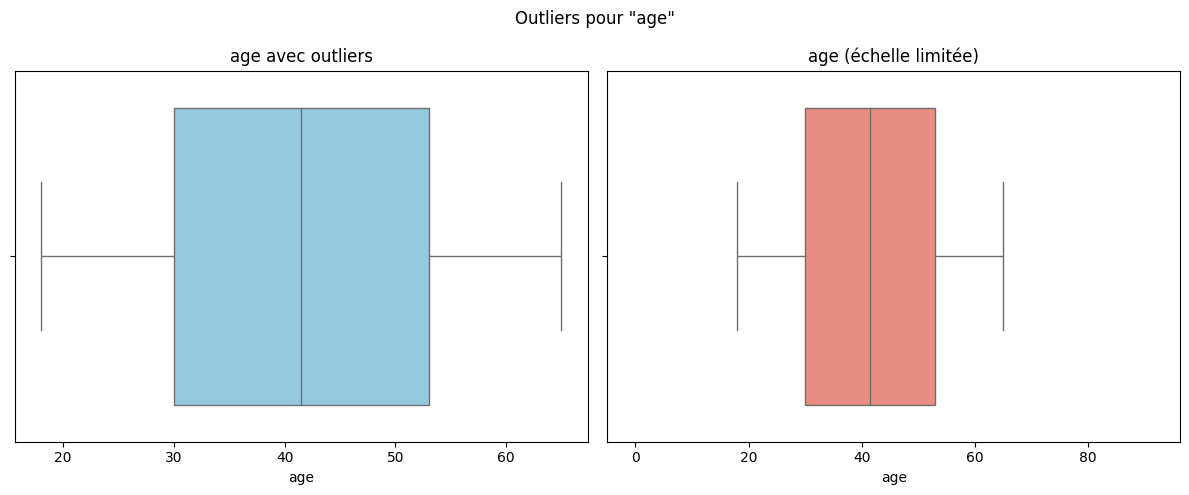


📊 **Variable : stress_level**
Nombre d'outliers : 0
Limites IQR : -4.50 - 15.50
Pourcentage d'outliers : 0.00%


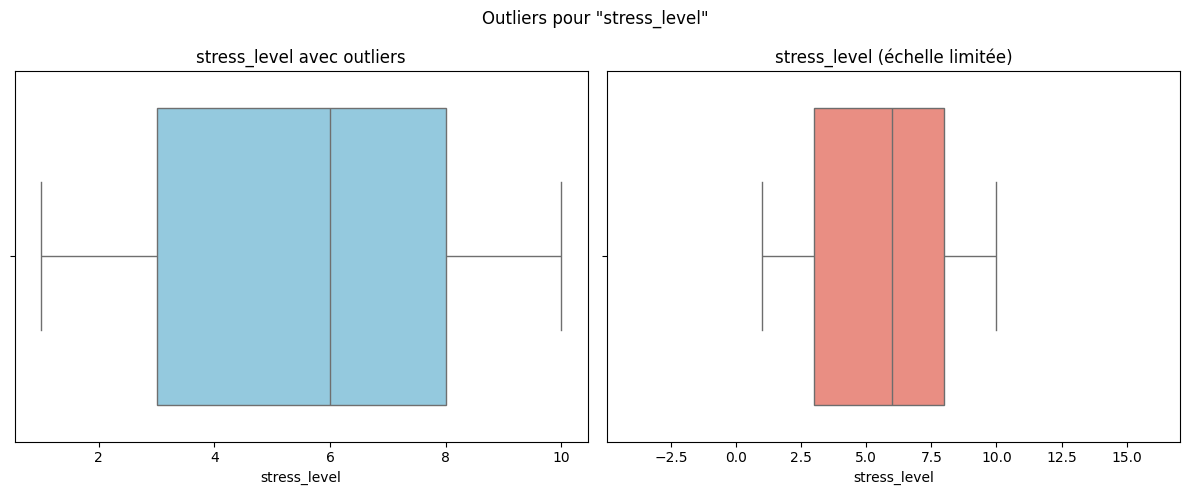


📊 **Variable : sleep_hours**
Nombre d'outliers : 0
Limites IQR : 2.50 - 10.50
Pourcentage d'outliers : 0.00%


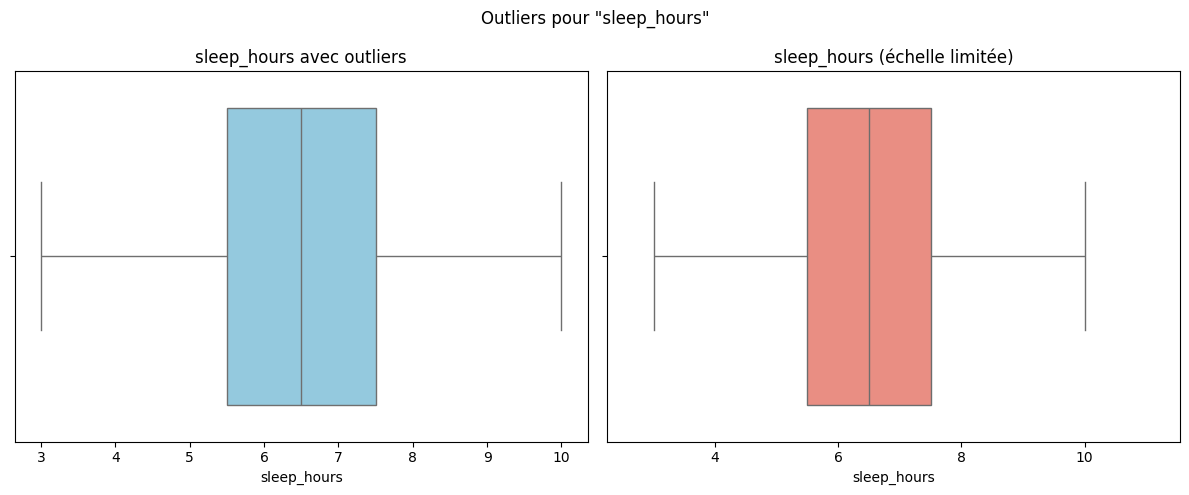


📊 **Variable : physical_activity_days**
Nombre d'outliers : 0
Limites IQR : -2.50 - 9.50
Pourcentage d'outliers : 0.00%


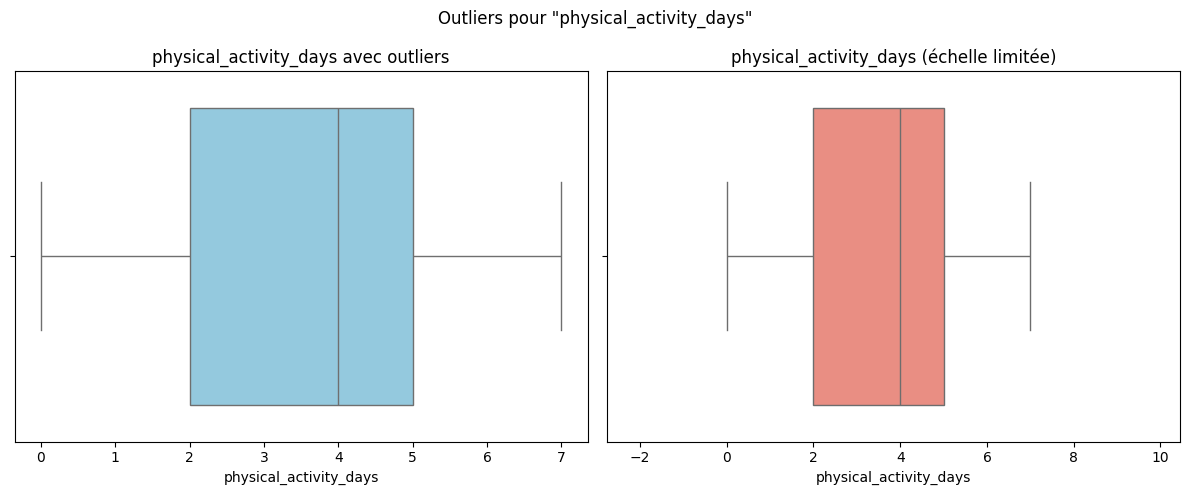


📊 **Variable : depression_score**
Nombre d'outliers : 0
Limites IQR : -17.00 - 47.00
Pourcentage d'outliers : 0.00%


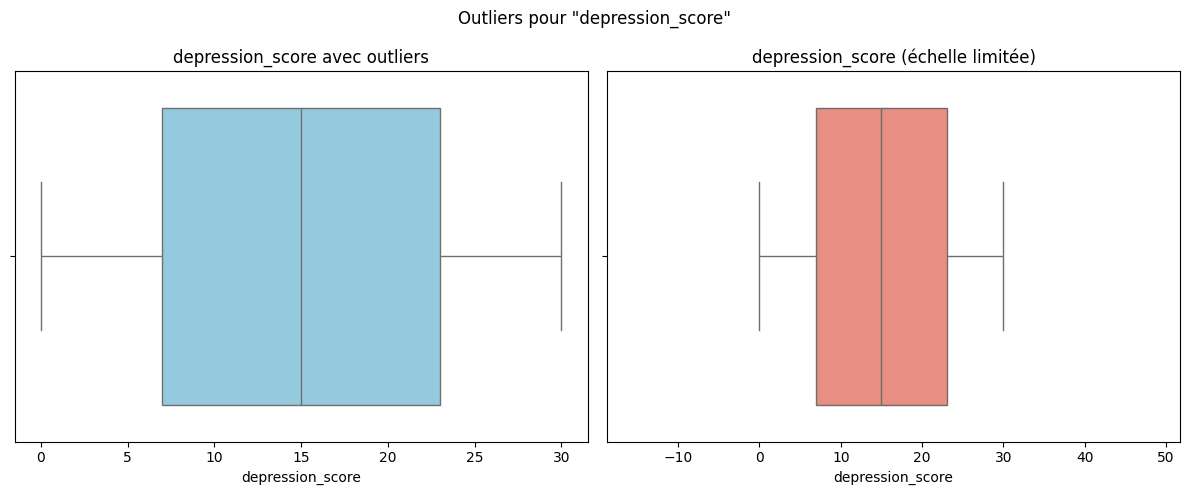


📊 **Variable : anxiety_score**
Nombre d'outliers : 0
Limites IQR : -11.50 - 32.50
Pourcentage d'outliers : 0.00%


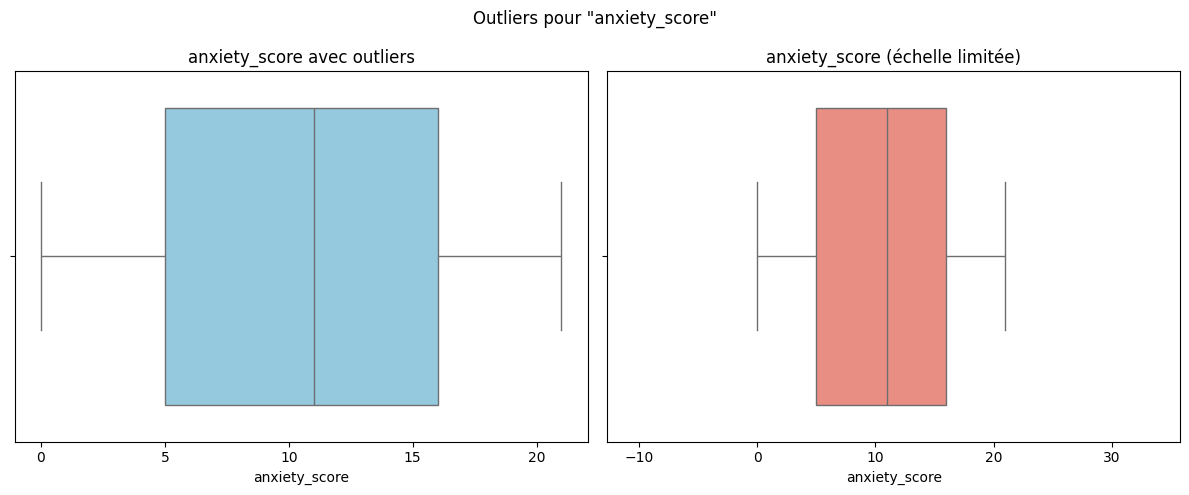


📊 **Variable : social_support_score**
Nombre d'outliers : 0
Limites IQR : -51.50 - 152.50
Pourcentage d'outliers : 0.00%


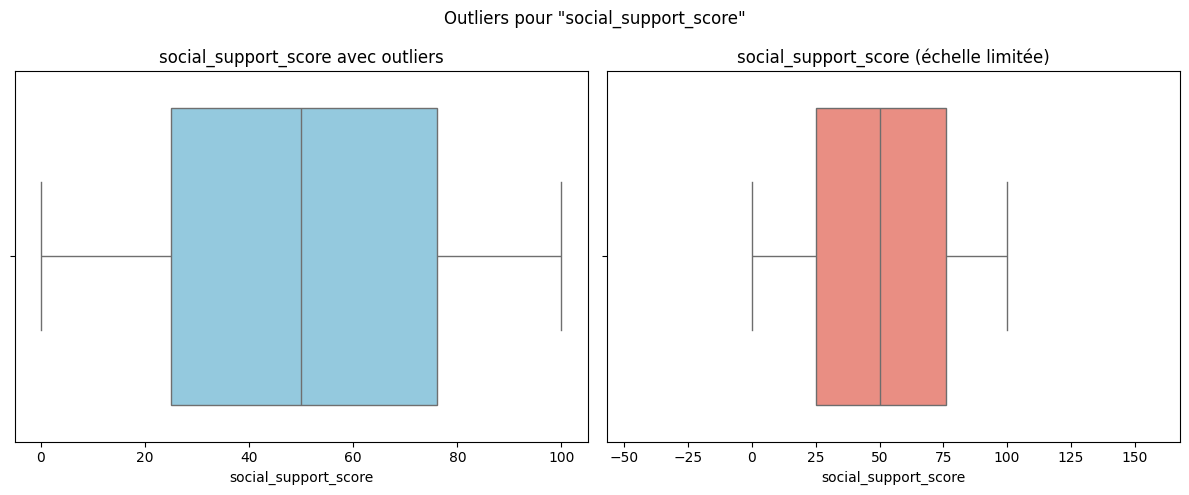


📊 **Variable : productivity_score**
Nombre d'outliers : 0
Limites IQR : 30.70 - 124.30
Pourcentage d'outliers : 0.00%


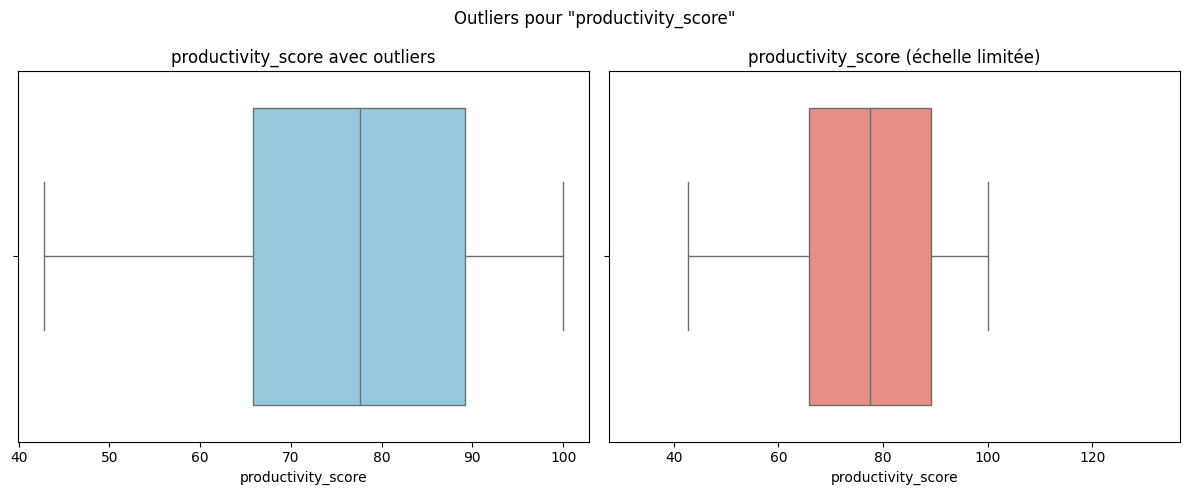

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fonction de détection des outliers par la méthode IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper


# Colonnes numériques à analyser
numeric_columns = [
    'age', 'stress_level', 'sleep_hours', 'physical_activity_days',
    'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score'
]

# Boucle sur chaque variable numérique
for col in numeric_columns:
    if df[col].dtype in ['int64', 'float64']:
        outliers, lower, upper = detect_outliers_iqr(df, col)
        percentage = 100 * len(outliers) / len(df)

        print(f"\n📊 **Variable : {col}**")
        print(f"Nombre d'outliers : {len(outliers)}")
        print(f"Limites IQR : {lower:.2f} - {upper:.2f}")
        print(f"Pourcentage d'outliers : {percentage:.2f}%")

        # Visualisation
        plt.figure(figsize=(12, 5))

        # Boxplot normal
        plt.subplot(1, 2, 1)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'{col} avec outliers')

        # Boxplot avec axe limité pour mieux voir
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color='salmon')
        plt.title(f'{col} (échelle limitée)')
        plt.xlim(lower - (0.1 * abs(lower)), upper + (0.1 * abs(upper)))

        plt.suptitle(f'Outliers pour "{col}"')
        plt.tight_layout()
        plt.savefig(f'outliers_{col}.png', dpi=300, bbox_inches='tight')
        plt.show()


### 6.2 Traitement des valeurs manquantes


<Figure size 1200x600 with 0 Axes>

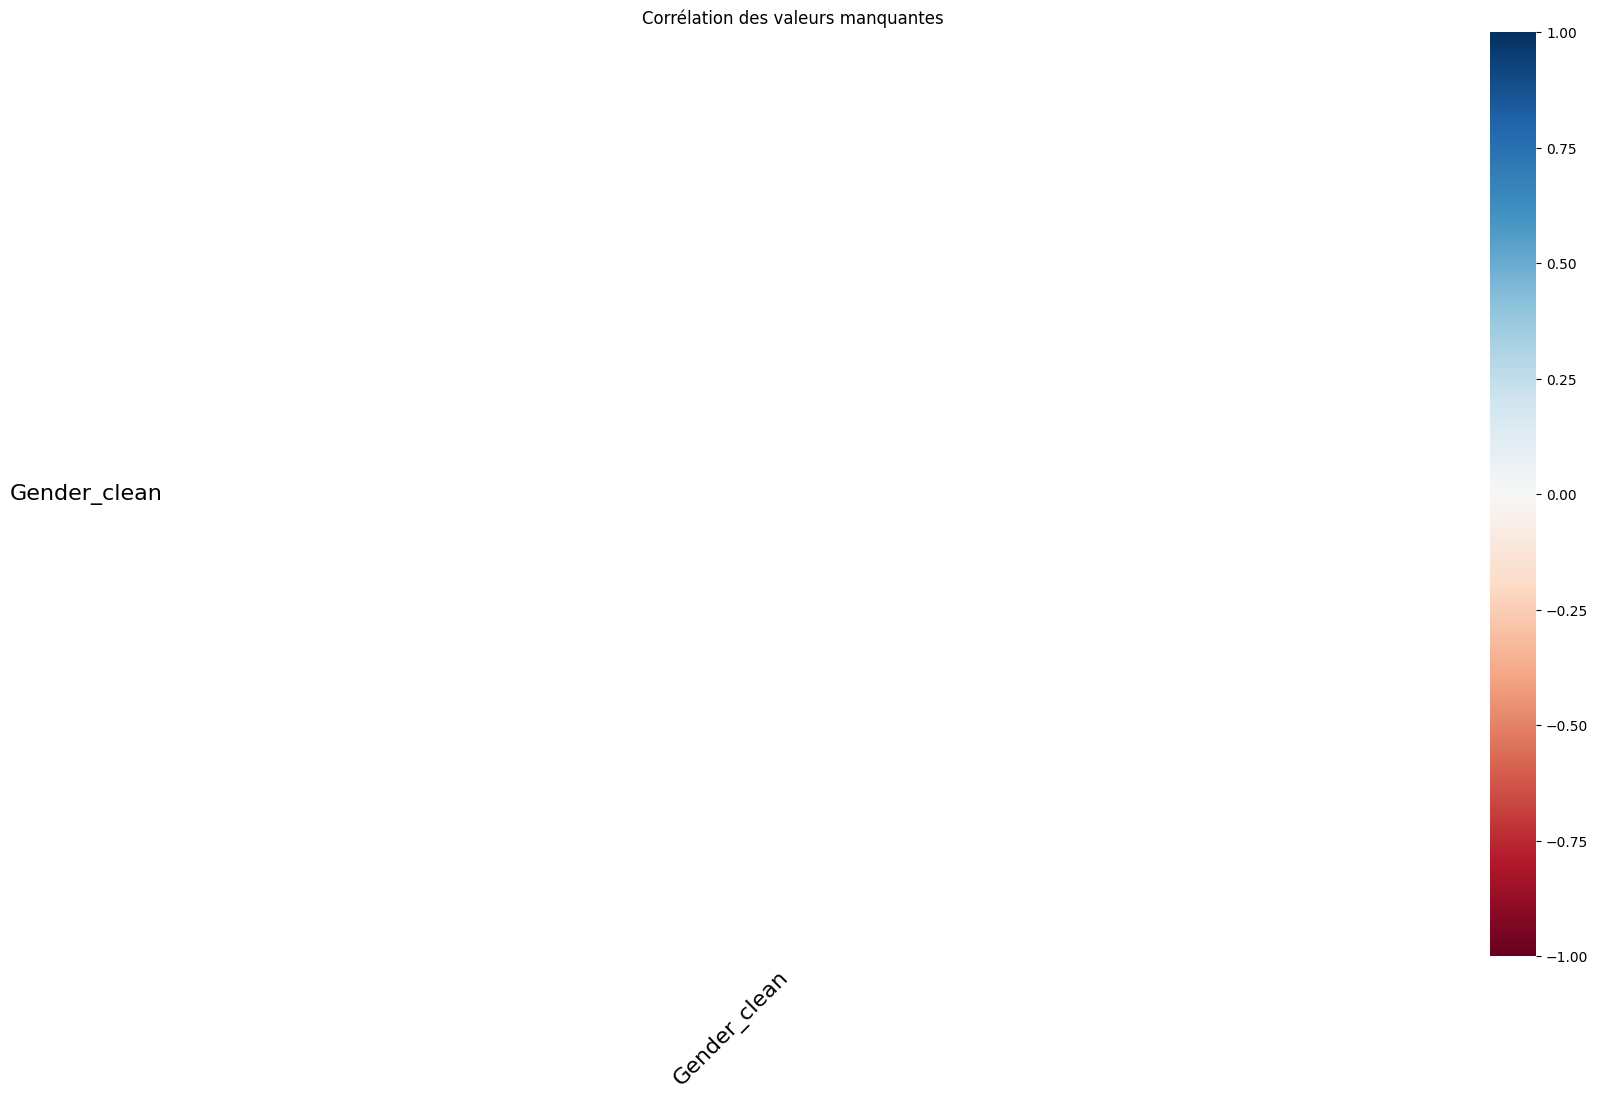

In [ ]:
# Analyse des patterns de valeurs manquantes
plt.figure(figsize=(12, 6))
msno.heatmap(df)
plt.title('Corrélation des valeurs manquantes')
plt.savefig('missing_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Original DataFrame shape
print(f"Original shape: {df.shape}")

df = df.dropna(subset=['Gender_clean'])

# Shape after dropping rows
print(f"Shape after dropping rows with missing Gender_clean: {df.shape}")

# Verify no missing values in 'Gender_clean' in the cleaned DataFrame
print("\nMissing values in df after dropping:")
print(df_clean['Gender_clean'].isnull().sum())

Original shape: (9534, 18)
Shape after dropping rows with missing Gender_clean: (9534, 18)

Missing values in df_clean after dropping:
0


In [ ]:
df= df.drop('gender', axis=1)

KeyError: "['gender'] not found in axis"

#**Partie de Ijlal Sellak**

##Synthèse des découvertes EDA

- Les individus peuvent être regroupés en 3 profils bien distincts grâce au clustering KMeans.
- Le **Cluster 0** présente une **forte dépression** et une **basse productivité** → **profil à risque élevé**.
- Le **Cluster 1** est très **productif malgré l’anxiété** mais a **peu de soutien social** → **profil fragile**.
- Le **Cluster 2** est **équilibré**, avec **haut soutien social** et bonne performance.
- Les tests du Chi² ont révélé **peu d’associations significatives** entre les variables catégorielles, à l’exception de `Gender` et `Gender_clean`.
- Les boxplots montrent une influence marquée du soutien social, de la dépression et du stress sur la productivité.

Ces résultats orientent vers des axes d’optimisation et de prévention en entreprise autour du **bien-être psychologique**.


##Feature Engineering

In [ ]:
# Créer une variable binaire : haut risque mental
df['high_mental_risk'] = ((df['depression_score'] > 20) | (df['anxiety_score'] > 15)).astype(int)

# Catégoriser le stress
df['stress_category'] = pd.cut(df['stress_level'], bins=[0, 3, 6, 10], labels=['faible', 'modéré', 'élevé'])

# Sommeil insuffisant ?
df['sleep_deficit'] = (df['sleep_hours'] < 6).astype(int)

# Support social suffisant ?
df['support_category'] = pd.cut(df['social_support_score'], bins=[0, 30, 60, 100], labels=['faible', 'moyen', 'fort'])


##Nettoyage final

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Encodage des variables catégorielles
categorical_encoded = pd.get_dummies(df[['employment_status', 'work_environment', 'stress_category', 'support_category']], drop_first=True)

# Concatenation avec les variables numériques
df_final = pd.concat([df[numeric_cols], categorical_encoded, df[['high_mental_risk', 'sleep_deficit']]], axis=1)

# Vérification finale
df_final.head()


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,work_environment_On-site,work_environment_Remote,stress_category_modéré,stress_category_élevé,support_category_moyen,support_category_fort,high_mental_risk,sleep_deficit
0,56,6,6.2,3,28,17,54,59.7,False,False,False,True,False,True,False,True,False,1,0
1,46,10,9.0,4,30,11,85,54.9,False,True,False,True,False,False,True,False,True,1,0
2,32,7,7.7,2,24,7,62,61.3,False,False,False,True,False,False,True,False,True,1,0
3,60,4,4.5,4,6,0,95,97.0,True,False,False,True,False,True,False,False,True,0,1
4,25,3,5.4,0,24,12,70,69.0,True,False,False,True,False,False,False,False,True,1,1


##Exemple de Modélisation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df_final.drop('high_mental_risk', axis=1)
y = df_final['high_mental_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[917   0]
 [  0 990]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       917
           1       1.00      1.00      1.00       990

    accuracy                           1.00      1907
   macro avg       1.00      1.00      1.00      1907
weighted avg       1.00      1.00      1.00      1907



## Visualisation finale & storytelling

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


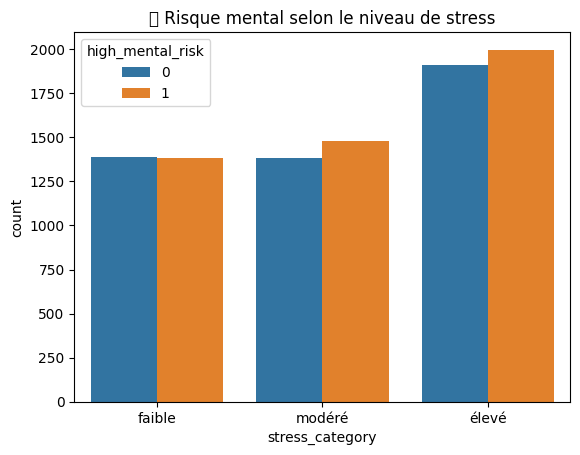

In [ ]:
# Visualiser la répartition du risque mental par catégorie de stress
sns.countplot(x='stress_category', hue='high_mental_risk', data=df)
plt.title(" Risque mental selon le niveau de stress")
plt.show()
